In [287]:
import numpy as np
import random
import matplotlib.pyplot as plt # Graphical library
from sklearn.metrics import mean_squared_error # Mean-squared error function

# Coursework 1 :
See pdf for instructions.

In [2]:
# WARNING: DO NOT CHANGE THE VALUES

def get_ID():
  return "01610093"

def get_login():
  return "mf4618"

## Helper class

In [3]:
# This class is used ONLY for graphics
# YOU DO NOT NEED to understand it to work on this coursework

class GraphicsMaze(object):

  def __init__(self, shape, locations, default_reward, obstacle_locs, absorbing_locs, absorbing_rewards, absorbing):

    self.shape = shape
    self.locations = locations
    self.absorbing = absorbing

    # Walls
    self.walls = np.zeros(self.shape)
    for ob in obstacle_locs:
      self.walls[ob] = 20

    # Rewards
    self.rewarders = np.ones(self.shape) * default_reward
    for i, rew in enumerate(absorbing_locs):
      self.rewarders[rew] = 10 if absorbing_rewards[i] > 0 else -10

    # Print the map to show it
    self.paint_maps()

  def paint_maps(self):
    """
    Print the Maze topology (obstacles, absorbing states and rewards)
    input: /
    output: /
    """
    plt.figure(figsize=(15,10))
    plt.imshow(self.walls + self.rewarders)
    plt.show()

  def paint_state(self, state):
    """
    Print one state on the Maze topology (obstacles, absorbing states and rewards)
    input: /
    output: /
    """
    states = np.zeros(self.shape)
    states[state] = 30
    plt.figure(figsize=(15,10))
    plt.imshow(self.walls + self.rewarders + states)
    plt.show()

  def draw_deterministic_policy(self, Policy):
    """
    Draw a deterministic policy
    input: Policy {np.array} -- policy to draw (should be an array of values between 0 and 3 (actions))
    output: /
    """
    plt.figure(figsize=(15,10))
    plt.imshow(self.walls + self.rewarders) # Create the graph of the Maze
    for state, action in enumerate(Policy):
      if(self.absorbing[0,state]): # If it is an absorbing state, don't plot any action
        continue
      arrows = [r"$\uparrow$",r"$\rightarrow$", r"$\downarrow$", r"$\leftarrow$"] # List of arrows corresponding to each possible action
      action_arrow = arrows[action] # Take the corresponding action
      location = self.locations[state] # Compute its location on graph
      plt.text(location[1], location[0], action_arrow, ha='center', va='center') # Place it on graph
    plt.show()

  def draw_policy(self, Policy):
    """
    Draw a policy (draw an arrow in the most probable direction)
    input: Policy {np.array} -- policy to draw as probability
    output: /
    """
    deterministic_policy = np.array([np.argmax(Policy[row,:]) for row in range(Policy.shape[0])])
    self.draw_deterministic_policy(deterministic_policy)

  def draw_value(self, Value):
    """
    Draw a policy value
    input: Value {np.array} -- policy values to draw
    output: /
    """
    plt.figure(figsize=(15,10))
    plt.imshow(self.walls + self.rewarders) # Create the graph of the Maze
    for state, value in enumerate(Value):
      if(self.absorbing[0, state]): # If it is an absorbing state, don't plot any value
        continue
      location = self.locations[state] # Compute the value location on graph
      plt.text(location[1], location[0], round(value,2), ha='center', va='center') # Place it on graph
    plt.show()

  def draw_deterministic_policy_grid(self, Policies, title, n_columns, n_lines):
    """
    Draw a grid representing multiple deterministic policies
    input: Policies {np.array of np.array} -- array of policies to draw (each should be an array of values between 0 and 3 (actions))
    output: /
    """
    plt.figure(figsize=(20,8))
    for subplot in range (len(Policies)): # Go through all policies
      ax = plt.subplot(n_columns, n_lines, subplot+1) # Create a subplot for each policy
      ax.imshow(self.walls+self.rewarders) # Create the graph of the Maze
      for state, action in enumerate(Policies[subplot]):
        if(self.absorbing[0,state]): # If it is an absorbing state, don't plot any action
          continue
        arrows = [r"$\uparrow$",r"$\rightarrow$", r"$\downarrow$", r"$\leftarrow$"] # List of arrows corresponding to each possible action
        action_arrow = arrows[action] # Take the corresponding action
        location = self.locations[state] # Compute its location on graph
        plt.text(location[1], location[0], action_arrow, ha='center', va='center') # Place it on graph
      ax.title.set_text(title[subplot]) # Set the title for the graph given as argument
    plt.show()

  def draw_policy_grid(self, Policies, title, n_columns, n_lines):
    """
    Draw a grid representing multiple policies (draw an arrow in the most probable direction)
    input: Policy {np.array} -- array of policies to draw as probability
    output: /
    """
    deterministic_policies = np.array([[np.argmax(Policy[row,:]) for row in range(Policy.shape[0])] for Policy in Policies])
    self.draw_deterministic_policy_grid(deterministic_policies, title, n_columns, n_lines)

  def draw_value_grid(self, Values, title, n_columns, n_lines):
    """
    Draw a grid representing multiple policy values
    input: Values {np.array of np.array} -- array of policy values to draw
    output: /
    """
    plt.figure(figsize=(20,8))
    for subplot in range (len(Values)): # Go through all values
      ax = plt.subplot(n_columns, n_lines, subplot+1) # Create a subplot for each value
      ax.imshow(self.walls+self.rewarders) # Create the graph of the Maze
      for state, value in enumerate(Values[subplot]):
        if(self.absorbing[0,state]): # If it is an absorbing state, don't plot any value
          continue
        location = self.locations[state] # Compute the value location on graph
        plt.text(location[1], location[0], round(value,1), ha='center', va='center') # Place it on graph
      ax.title.set_text(title[subplot]) # Set the title for the graoh given as argument
    plt.show()


## Maze class

In [212]:
# This class define the Maze environment

class Maze(object):

  # [Action required]
  def __init__(self):
    """
    Maze initialisation.
    input: /
    output: /
    """

    # [Action required]
    # Properties set from the CID
    self._prob_success = 0.8 # float, p = 0.8 + 0.02*(9 - y) = 0.8 since y = 9
    self._gamma = 0.98 # float, gamma = 0.8 + 0.02*9 = 0.98
    self._goal = 3 # integer (0 for R0, 1 for R1, 2 for R2, 3 for R3), goal = 3 since z%4 = 3

    # Build the maze
    self._build_maze()


  # Functions used to build the Maze environment
  # You DO NOT NEED to modify them
  def _build_maze(self):
    """
    Maze initialisation.
    input: /
    output: /
    """

    # Properties of the maze
    self._shape = (13, 10)
    self._obstacle_locs = [
                          (1,0), (1,1), (1,2), (1,3), (1,4), (1,7), (1,8), (1,9), \
                          (2,1), (2,2), (2,3), (2,7), \
                          (3,1), (3,2), (3,3), (3,7), \
                          (4,1), (4,7), \
                          (5,1), (5,7), \
                          (6,5), (6,6), (6,7), \
                          (8,0), \
                          (9,0), (9,1), (9,2), (9,6), (9,7), (9,8), (9,9), \
                          (10,0)
                         ] # Location of obstacles
    self._absorbing_locs = [(2,0), (2,9), (10,1), (12,9)] # Location of absorbing states
    self._absorbing_rewards = [ (500 if (i == self._goal) else -50) for i in range (4) ]
    self._starting_locs = [(0,0), (0,1), (0,2), (0,3), (0,4), (0,5), (0,6), (0,7), (0,8), (0,9)] #Reward of absorbing states
    self._default_reward = -1 # Reward for each action performs in the environment
    self._max_t = 500 # Max number of steps in the environment

    # Actions
    self._action_size = 4
    self._direction_names = ['N','E','S','W'] # Direction 0 is 'N', 1 is 'E' and so on

    # States
    self._locations = []
    for i in range (self._shape[0]):
      for j in range (self._shape[1]):
        loc = (i,j)
        # Adding the state to locations if it is no obstacle
        if self._is_location(loc):
          self._locations.append(loc)
    self._state_size = len(self._locations)

    # Neighbours - each line is a state, ranked by state-number, each column is a direction (N, E, S, W)
    self._neighbours = np.zeros((self._state_size, 4))

    for state in range(self._state_size):
      loc = self._get_loc_from_state(state)

      # North
      neighbour = (loc[0]-1, loc[1]) # North neighbours location
      if self._is_location(neighbour):
        self._neighbours[state][self._direction_names.index('N')] = self._get_state_from_loc(neighbour)
      else: # If there is no neighbour in this direction, coming back to current state
        self._neighbours[state][self._direction_names.index('N')] = state

      # East
      neighbour = (loc[0], loc[1]+1) # East neighbours location
      if self._is_location(neighbour):
        self._neighbours[state][self._direction_names.index('E')] = self._get_state_from_loc(neighbour)
      else: # If there is no neighbour in this direction, coming back to current state
        self._neighbours[state][self._direction_names.index('E')] = state

      # South
      neighbour = (loc[0]+1, loc[1]) # South neighbours location
      if self._is_location(neighbour):
        self._neighbours[state][self._direction_names.index('S')] = self._get_state_from_loc(neighbour)
      else: # If there is no neighbour in this direction, coming back to current state
        self._neighbours[state][self._direction_names.index('S')] = state

      # West
      neighbour = (loc[0], loc[1]-1) # West neighbours location
      if self._is_location(neighbour):
        self._neighbours[state][self._direction_names.index('W')] = self._get_state_from_loc(neighbour)
      else: # If there is no neighbour in this direction, coming back to current state
        self._neighbours[state][self._direction_names.index('W')] = state

    # Absorbing
    self._absorbing = np.zeros((1, self._state_size))
    for a in self._absorbing_locs:
      absorbing_state = self._get_state_from_loc(a)
      self._absorbing[0, absorbing_state] = 1

    # Transition matrix
    self._T = np.zeros((self._state_size, self._state_size, self._action_size)) # Empty matrix of dimension S*S*A
    for action in range(self._action_size):
      for outcome in range(4): # For each direction (N, E, S, W)
        # The agent has prob_success probability to go in the correct direction
        if action == outcome:
          prob = 1 - 3.0 * ((1.0 - self._prob_success) / 3.0) # (theoritically equal to self.prob_success but avoid rounding error and garanty a sum of 1)
        # Equal probability to go into one of the other directions
        else:
          prob = (1.0 - self._prob_success) / 3.0

        # Write this probability in the transition matrix
        for prior_state in range(self._state_size):
          # If absorbing state, probability of 0 to go to any other states
          if not self._absorbing[0, prior_state]:
            post_state = self._neighbours[prior_state, outcome] # Post state number
            post_state = int(post_state) # Transform in integer to avoid error
            self._T[prior_state, post_state, action] += prob

    # Reward matrix
    self._R = np.ones((self._state_size, self._state_size, self._action_size)) # Matrix filled with 1
    self._R = self._default_reward * self._R # Set default_reward everywhere
    for i in range(len(self._absorbing_rewards)): # Set absorbing states rewards
      post_state = self._get_state_from_loc(self._absorbing_locs[i])
      self._R[:,post_state,:] = self._absorbing_rewards[i]

    # Creating the graphical Maze world
    self._graphics = GraphicsMaze(self._shape, self._locations, self._default_reward, self._obstacle_locs, self._absorbing_locs, self._absorbing_rewards, self._absorbing)

    # Reset the environment
    self.reset()


  def _is_location(self, loc):
    """
    Is the location a valid state (not out of Maze and not an obstacle)
    input: loc {tuple} -- location of the state
    output: _ {bool} -- is the location a valid state
    """
    if (loc[0] < 0 or loc[1] < 0 or loc[0] > self._shape[0]-1 or loc[1] > self._shape[1]-1):
      return False
    elif (loc in self._obstacle_locs):
      return False
    else:
      return True


  def _get_state_from_loc(self, loc):
    """
    Get the state number corresponding to a given location
    input: loc {tuple} -- location of the state
    output: index {int} -- corresponding state number
    """
    return self._locations.index(tuple(loc))


  def _get_loc_from_state(self, state):
    """
    Get the state number corresponding to a given location
    input: index {int} -- state number
    output: loc {tuple} -- corresponding location
    """
    return self._locations[state]

  # Getter functions used only for DP agents
  # You DO NOT NEED to modify them
  def get_T(self):
    return self._T

  def get_R(self):
    return self._R

  def get_absorbing(self):
    return self._absorbing

  # Getter functions used for DP, MC and TD agents
  # You DO NOT NEED to modify them
  def get_graphics(self):
    return self._graphics

  def get_action_size(self):
    return self._action_size

  def get_state_size(self):
    return self._state_size

  def get_gamma(self):
    return self._gamma

  # Functions used to perform episodes in the Maze environment
  def reset(self):
    """
    Reset the environment state to one of the possible starting states
    input: /
    output:
      - t {int} -- current timestep
      - state {int} -- current state of the envionment
      - reward {int} -- current reward
      - done {bool} -- True if reach a terminal state / 0 otherwise
    """
    self._t = 0
    self._state = self._get_state_from_loc(self._starting_locs[random.randrange(len(self._starting_locs))])
    self._reward = 0
    self._done = False
    return self._t, self._state, self._reward, self._done

  def step(self, action):
    """
    Perform an action in the environment
    input: action {int} -- action to perform
    output:
      - t {int} -- current timestep
      - state {int} -- current state of the envionment
      - reward {int} -- current reward
      - done {bool} -- True if reach a terminal state / 0 otherwise
    """

    # If environment already finished, print an error
    if self._done or self._absorbing[0, self._state]:
      print("Please reset the environment")
      return self._t, self._state, self._reward, self._done

    # Drawing a random number used for probaility of next state
    probability_success = random.uniform(0,1)

    # Look for the first possible next states (so get a reachable state even if probability_success = 0)
    new_state = 0
    while self._T[self._state, new_state, action] == 0:
      new_state += 1
    assert self._T[self._state, new_state, action] != 0, "Selected initial state should be probability 0, something might be wrong in the environment."

    # Find the first state for which probability of occurence matches the random value
    total_probability = self._T[self._state, new_state, action]
    while (total_probability < probability_success) and (new_state < self._state_size-1):
     new_state += 1
     total_probability += self._T[self._state, new_state, action]
    assert self._T[self._state, new_state, action] != 0, "Selected state should be probability 0, something might be wrong in the environment."

    # Setting new t, state, reward and done
    self._t += 1
    self._reward = self._R[self._state, new_state, action]
    self._done = self._absorbing[0, new_state] or self._t > self._max_t
    self._state = new_state
    return self._t, self._state, self._reward, self._done

Creating the Maze:



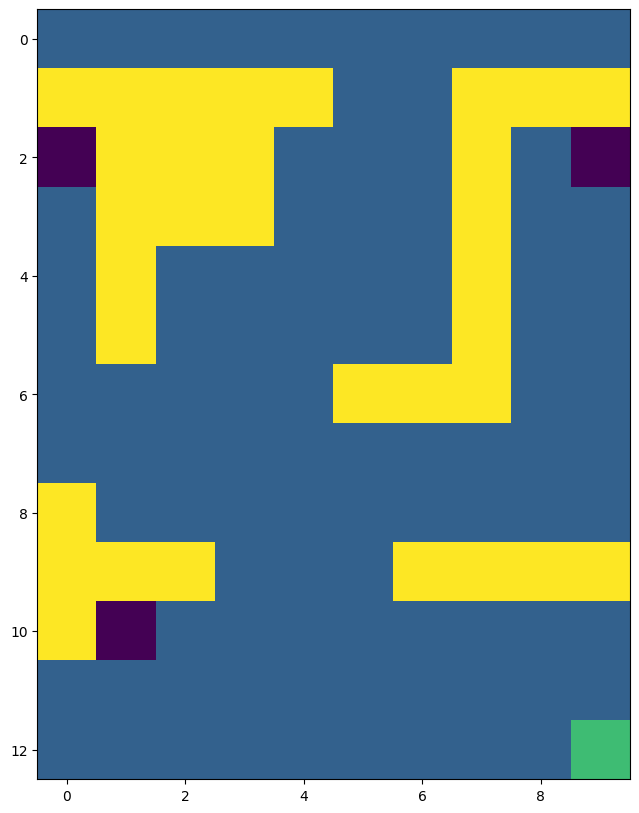

In [213]:
### Question 0: Defining the environment

print("Creating the Maze:\n")
maze = Maze()

## DP Agent

In [214]:
# This class define the Dynamic Programing agent

class DP_agent(object):

  # [Action required]
  # WARNING: make sure this function can be called by the auto-marking script

    def valueIteration(self, env, V):
        num_states = env.get_state_size()
        num_actions = env.get_action_size();
        gamma = env.get_gamma()
        
        T = env.get_T();
        R = env.get_R();
        absorbing = env.get_absorbing();

        #Value iteration to get the value function (asynchronous)
        while True: 
            delta = 0
            for i in range(num_states):
                V_old = V[i]
                
                if absorbing[0, i] == 1:
                    continue
                    
                a_values = [] #state-value for taking action a
                
                for a in range(num_actions):
                    a_values.append(np.sum(T[i, :, a] * (R[i, :, a] + gamma * V))) 
                
                V[i] = np.max(a_values)
                delta = max(delta, abs(V[i] - V_old))
                
            if delta < 0.001:
                break

        #Infer optimal policy from the value function
        policy = np.zeros((num_states, num_actions))
        for i in range(num_states):
            v_t = []
            for a in range(num_actions):
                v_t.append(np.sum(T[i, :, a] * (R[i, :, a] + gamma * V)))
                
            #index of action that gives the max value
            action = int(np.argmax(v_t))
            policy[i][action] = 1
            
        return policy, V

    def solve(self, env):
        """
        Solve a given Maze environment using Dynamic Programming
        input: env {Maze object} -- Maze to solve
        output:
          - policy {np.array} -- Optimal policy found to solve the given Maze environment
          - V {np.array} -- Corresponding value function
        """
    
        # Initialisation (can be edited)
        policy = np.zeros((env.get_state_size(), env.get_action_size()))
        V = np.zeros(env.get_state_size())
    
        ####
        # Add your code here
        # WARNING: for this agent only, you are allowed to access env.get_T(), env.get_R() and env.get_absorbing()
        ####
    
        policy, V = self.valueIteration(env, V)
    
        return policy, V

Results of the DP agent:



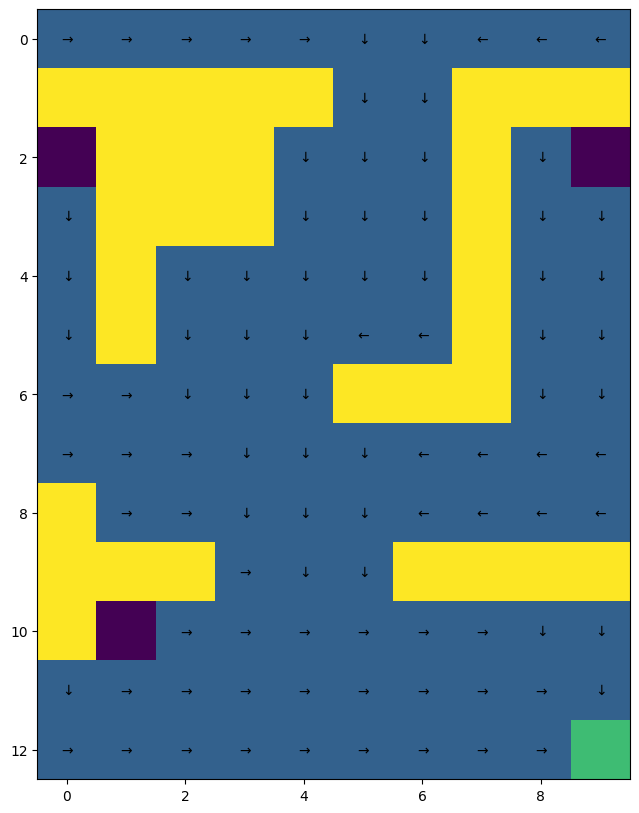

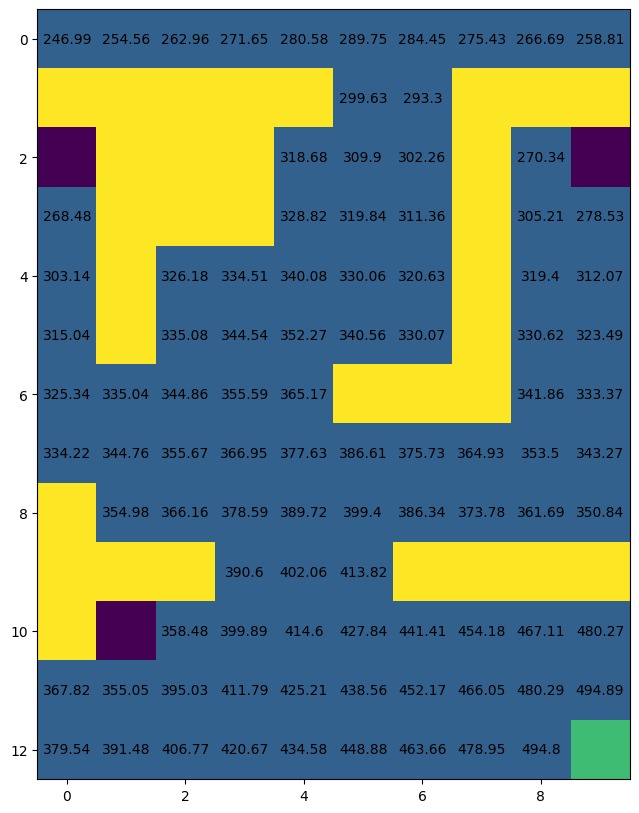

In [305]:
dp_agent = DP_agent()
dp_policy, dp_value = dp_agent.solve(maze)

print("Results of the DP agent:\n")
maze.get_graphics().draw_policy(dp_policy)
maze.get_graphics().draw_value(dp_value)

Results of the DP agent:



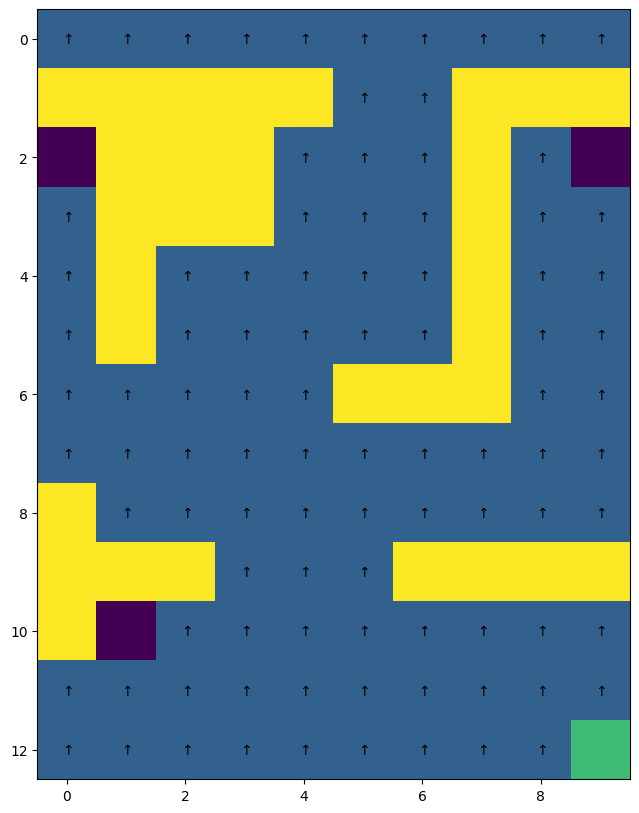

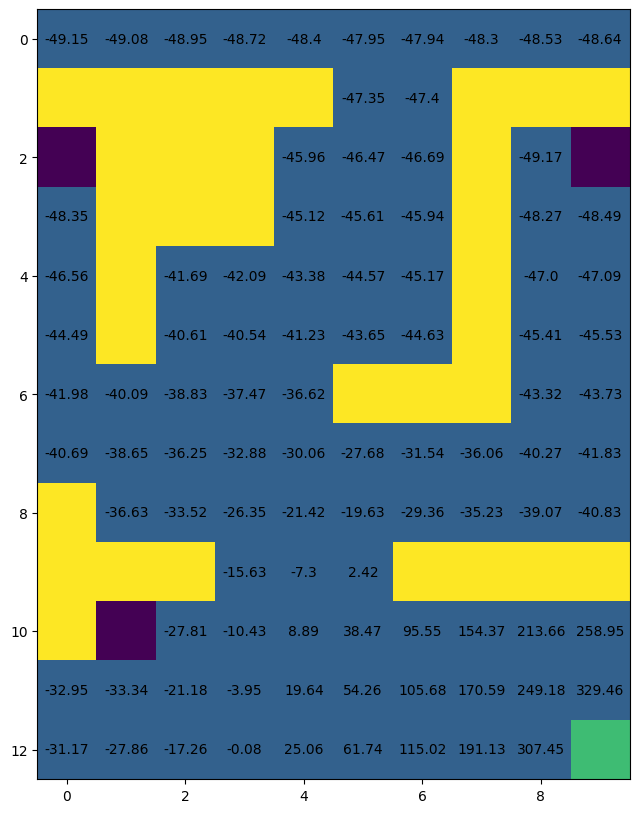

In [200]:
#for p = 0.25
dp_agent2 = DP_agent()
dp_policy2, dp_value2 = dp_agent2.solve(maze)

print("Results of the DP agent:\n")
maze.get_graphics().draw_policy(dp_policy2)
maze.get_graphics().draw_value(dp_value2)

Results of the DP agent:



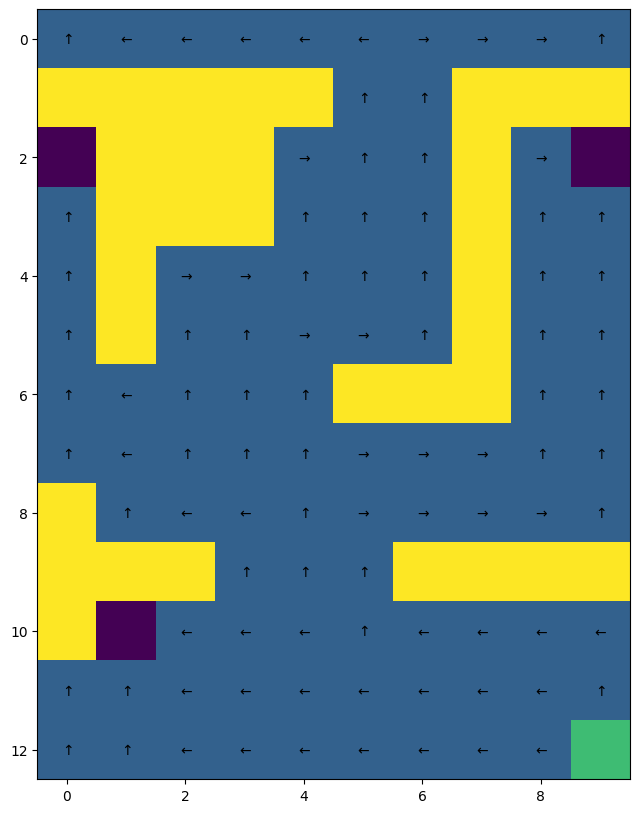

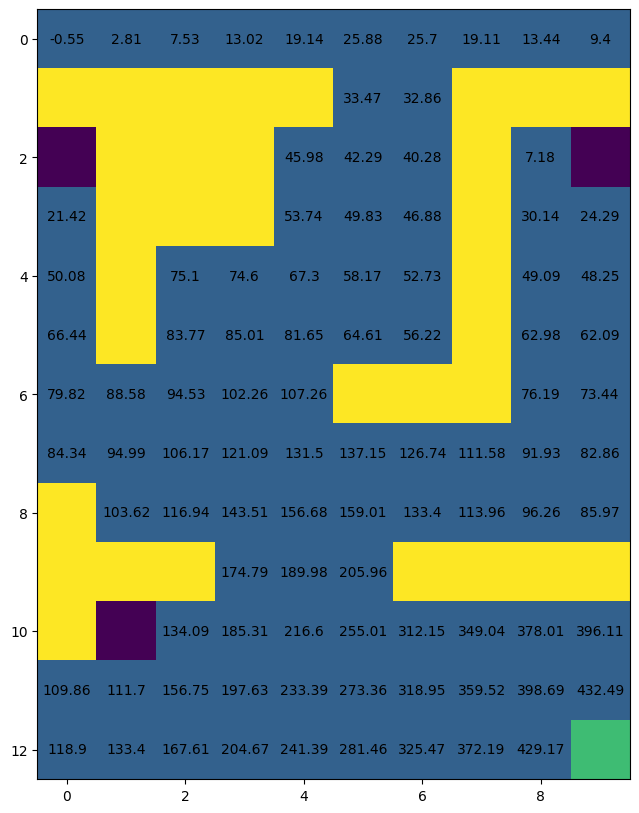

In [204]:
#for p = 0.1
dp_agent3 = DP_agent()
dp_policy3, dp_value3 = dp_agent3.solve(maze)

print("Results of the DP agent:\n")
maze.get_graphics().draw_policy(dp_policy3)
maze.get_graphics().draw_value(dp_value3)

Results of the DP agent:



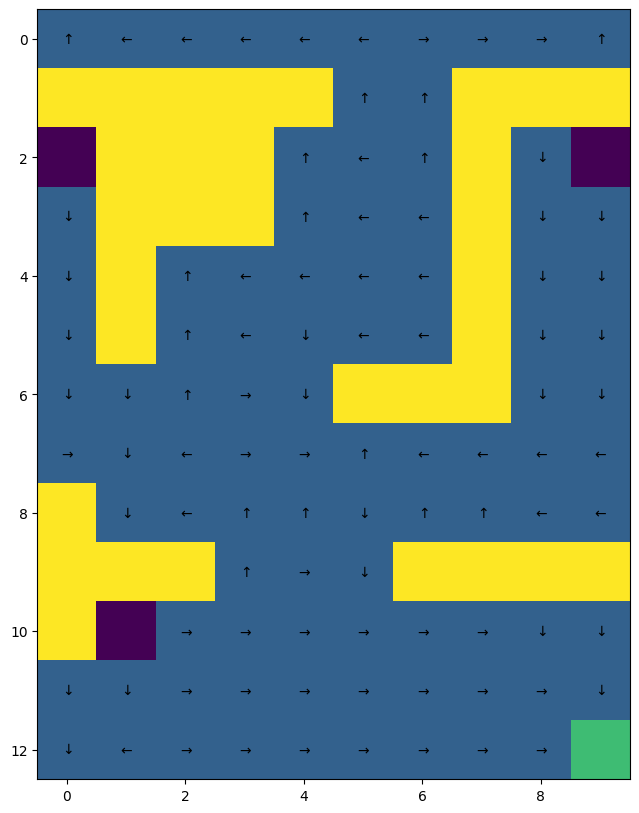

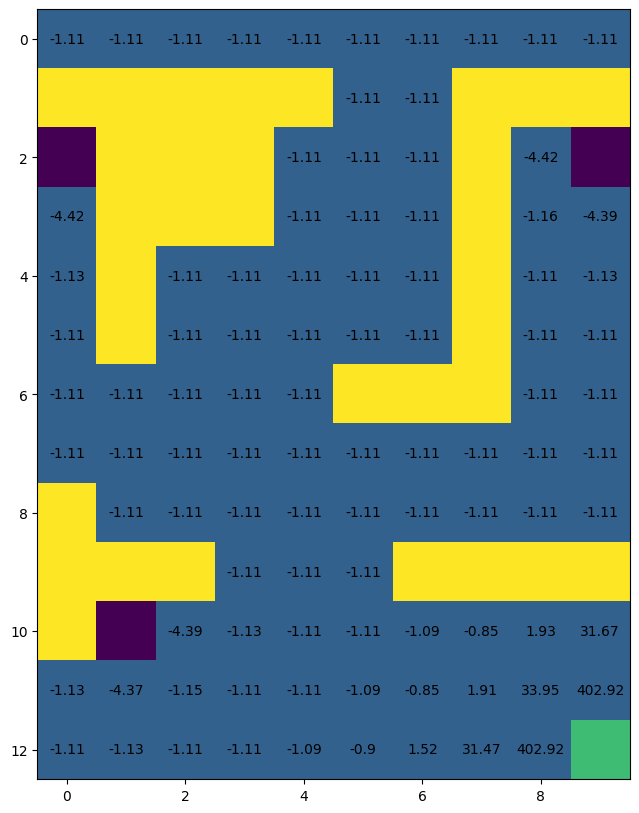

In [211]:
#for gamma = 0.1
dp_agent4 = DP_agent()
dp_policy4, dp_value4 = dp_agent4.solve(maze)

print("Results of the DP agent:\n")
maze.get_graphics().draw_policy(dp_policy4)
maze.get_graphics().draw_value(dp_value4)

## MC agent

In [309]:
# This class define the Monte-Carlo agent

class MC_agent(object):

  # [Action required]
  # WARNING: make sure this function can be called by the auto-marking script

  def generate_episode(self, env, policy):
    trace = []
    t, state_p, reward, done = env.reset();
    
    while not done: 
      action = np.random.choice(4, p=policy[state_p]) #out of 4 actions to choose, use the probabilities by policy 
      t, state, reward, done = env.step(action);
      trace.append((state_p, action, reward))
      state_p = state
      
    return trace

  def every_visit_MC(self, env, Q, V, policy, values, total_rewards, n, alpha, epsilon, gamma):
    num_states = env.get_state_size()
    num_actions = env.get_action_size();

    #for decaying epsilon
    #epsilon = 1.0
    #epsilon_min = 0.01
    #epsilon_decay = 0.9995

    for i in range(n):
        #generate episode
        trace = self.generate_episode(env, policy)

        #to get and store total_rewards value for this episode
        total_r = 0
        #to get and store a list of value_functions and update q for this episode  
        G = 0
        
        #N = np.zeros((num_states, num_actions)) for decaying alpha
        
        for s, a, r in reversed(trace):
            total_r += r
            G = r + gamma * G    
            #N[s][a] += 1
            #alpha = 1/N[s][a]
            Q[s][a] += alpha*(G - Q[s][a])

        total_rewards.append(total_r)
        values.append(np.sum(Q * policy, axis=1).copy())

        #epsilon greedy to get policy
        for s in range(num_states):                
            max_q_a = int(np.argmax(Q[s]))
            policy[s] = [(epsilon/4 if (i != max_q_a) else (1 - epsilon + epsilon/4)) for i in range (4)]

        #epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return policy, values, total_rewards
              
  def solve(self, env):
    """
    Solve a given Maze environment using Monte Carlo learning
    input: env {Maze object} -- Maze to solve
    output:
      - policy {np.array} -- Optimal policy found to solve the given Maze environment
      - values {list of np.array} -- List of successive value functions for each episode
      - total_rewards {list of float} -- Corresponding list of successive total non-discounted sum of reward for each episode
    """

    # Initialisation (can be edited)
    Q = np.random.rand(env.get_state_size(), env.get_action_size())
    V = np.zeros(env.get_state_size())
    policy = np.ones((env.get_state_size(), env.get_action_size())) / 4
    values = [V]
    total_rewards = []

    ####
    # Add your code here
    # WARNING: this agent only has access to env.reset() and env.step()
    # You should not use env.get_T(), env.get_R() or env.get_absorbing() to compute any value
    ####

    n = 10000 #num of episodes
    alpha = 0.01 #learning rate
    epsilon = 0.1 #exploration rate
    gamma = env.get_gamma()
      
    policy, values, total_rewards = self.every_visit_MC(env, Q, V, policy, values, total_rewards, n, alpha, epsilon, gamma)
      
    return policy, values, total_rewards

Results of the MC agent:



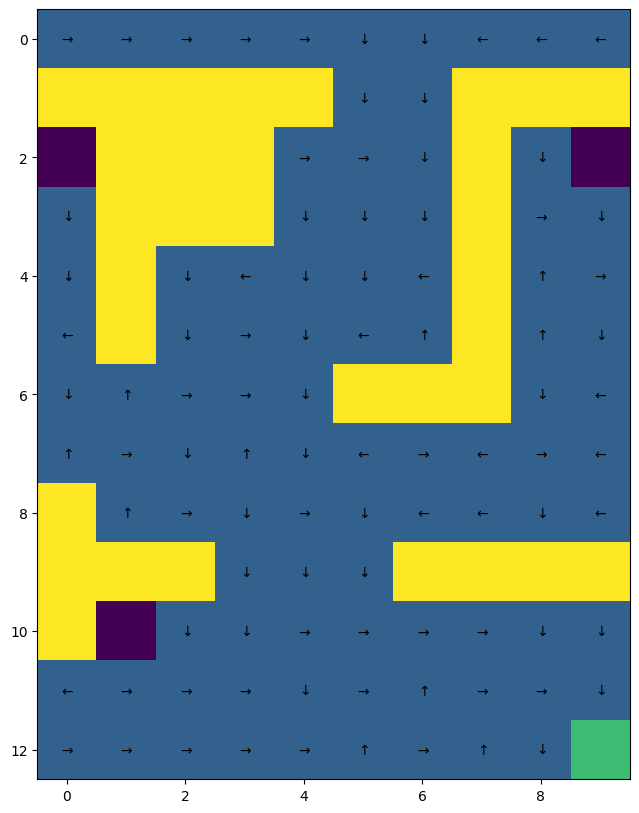

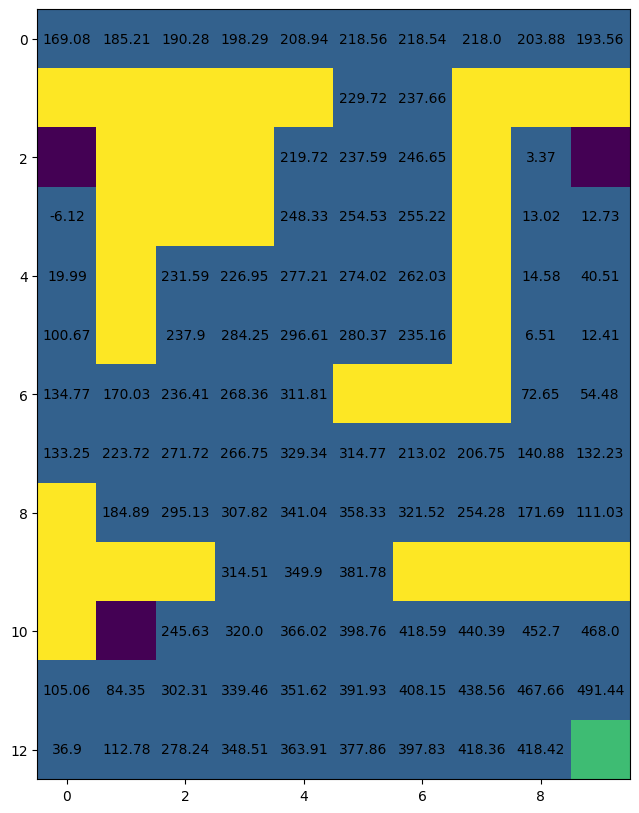

In [310]:
#run 1
mc_agent = MC_agent()
mc_policy, mc_values, total_rewards = mc_agent.solve(maze)

print("Results of the MC agent:\n")
maze.get_graphics().draw_policy(mc_policy)
maze.get_graphics().draw_value(mc_values[-1])

Results of the MC agent:



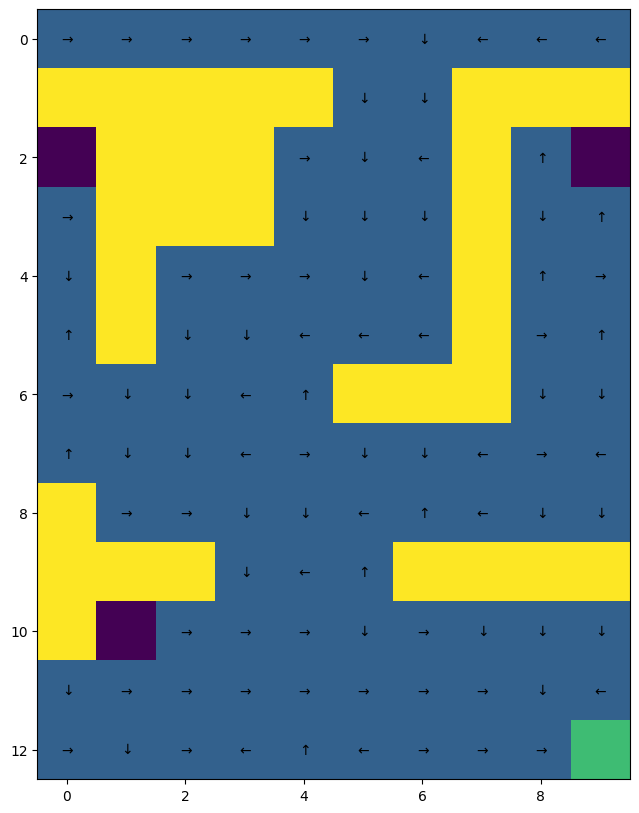

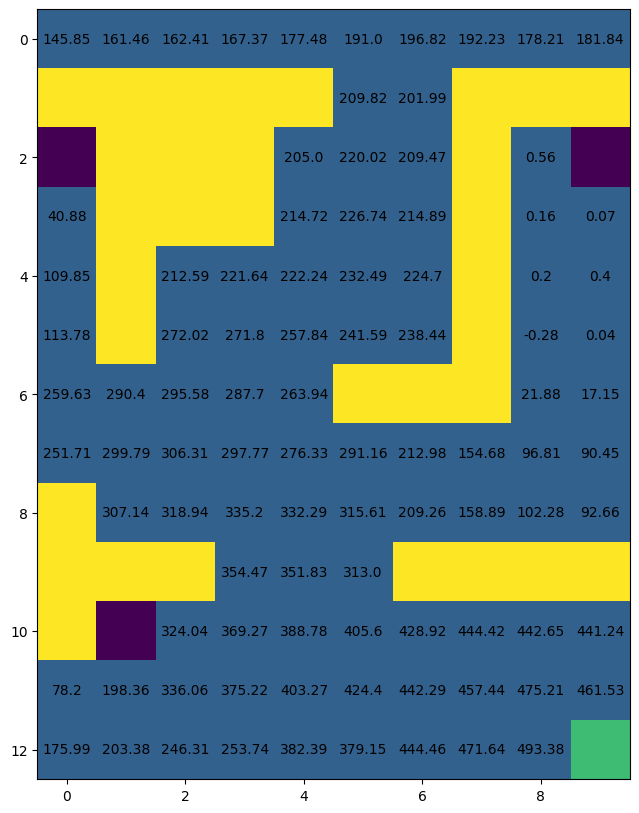

In [132]:
#run 2
mc_agent2 = MC_agent()
mc_policy2, mc_values2, total_rewards2 = mc_agent.solve(maze)

print("Results of the MC agent:\n")
maze.get_graphics().draw_policy(mc_policy2)
maze.get_graphics().draw_value(mc_values2[-1])

How to choose number of replications?

In [230]:
def plot_lc(mean_rewards, std_rewards):
    plt.plot(mean_rewards, label="MC Average") #average between different MC runs

    plt.fill_between(
        range(n),
        mean_rewards - std_rewards,
        mean_rewards + std_rewards,
        alpha=0.3
    )
    
    plt.xlabel("Episodes")
    plt.ylabel("Total Reward")
    plt.legend()
    plt.show()
    

Learning Curve with  1  Replication(s)


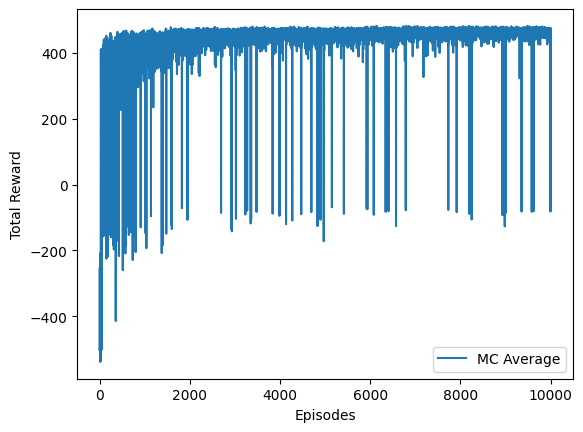

Learning Curve with  2  Replication(s)


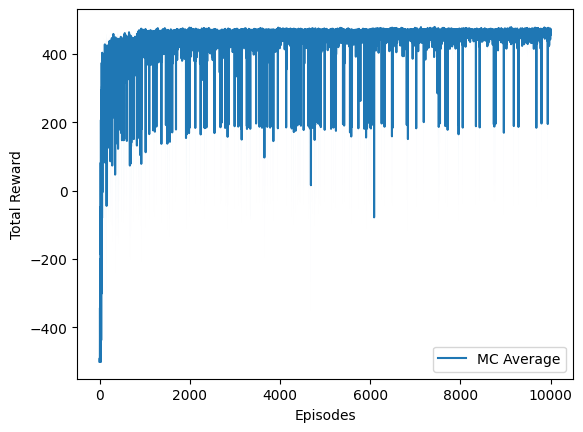

Learning Curve with  5  Replication(s)


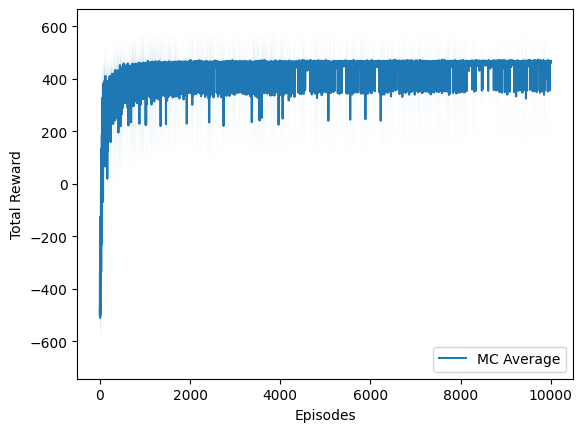

Learning Curve with  10  Replication(s)


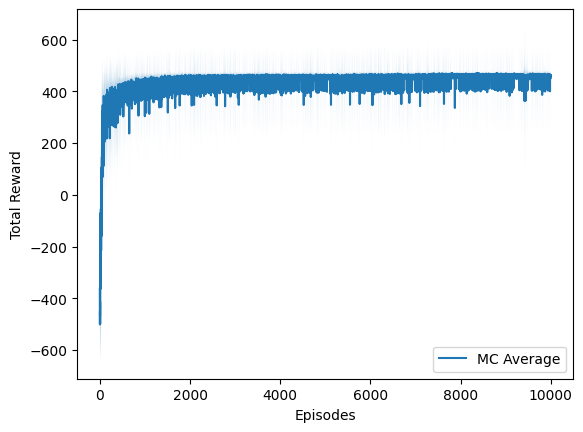

Learning Curve with  15  Replication(s)


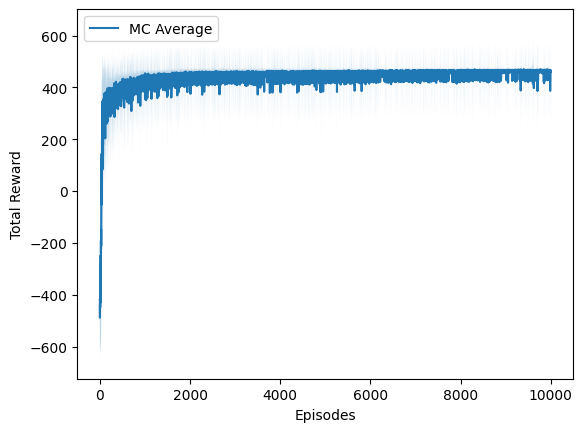

Learning Curve with  20  Replication(s)


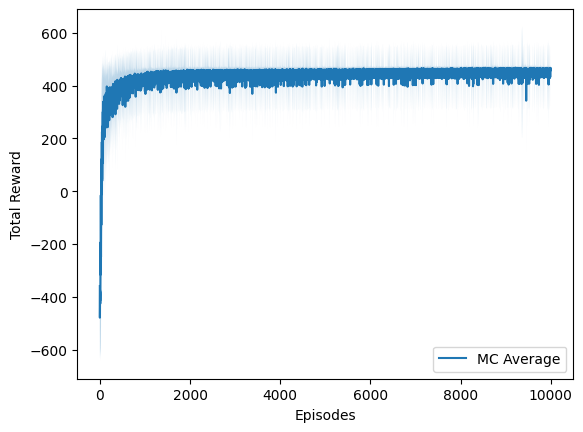

Learning Curve with  25  Replication(s)


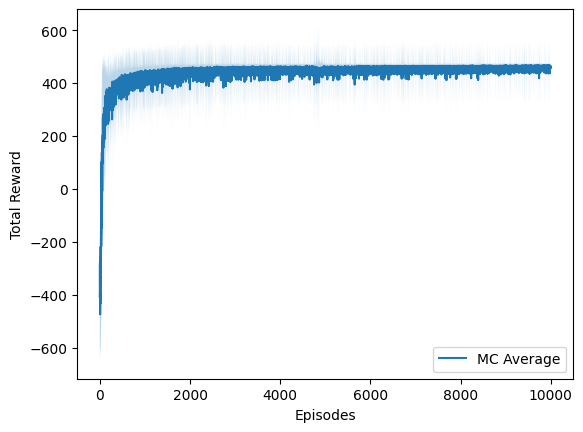

In [231]:
n = 10000 #num of episodes
replications = [1, 2, 5, 10, 15, 20, 25]

for num_run in replications:
    all_rewards = np.zeros((num_run, n))
    for r in range(num_run):
        agent = MC_agent()
        _, _, total_rewards = agent.solve(maze)
        all_rewards[r] = total_rewards

    #join different 
    mean_rewards = np.mean(all_rewards, axis=0)
    std_rewards = np.std(all_rewards, axis=0)

    print("Learning Curve with ", num_run, " Replication(s)");
    plot_lc(mean_rewards, std_rewards)

In [237]:
def plot_diff(mean_difference):
    window_size = 50  # smooth over 50 episodes
    kernel = np.ones(window_size) / window_size
    smoothed_diff = np.convolve(mean_difference, kernel, mode='valid')
    
    plt.figure(figsize=(10,5))
    plt.plot(mean_difference, label="Absolute Mean Difference (MC Agent 1 - MC Agent 2)")
    plt.axhline(0, color='black', linestyle='--', linewidth=1) 
    plt.xlabel("Episode")
    plt.ylabel("Difference in Total Reward")
    plt.title(f"Difference Between Two MC Agents' Mean Rewards")
    plt.legend()
    plt.grid(True)
    plt.show()

Absolute difference in mean reward between 2 different Multi MC-learning runs with num_replications= 2


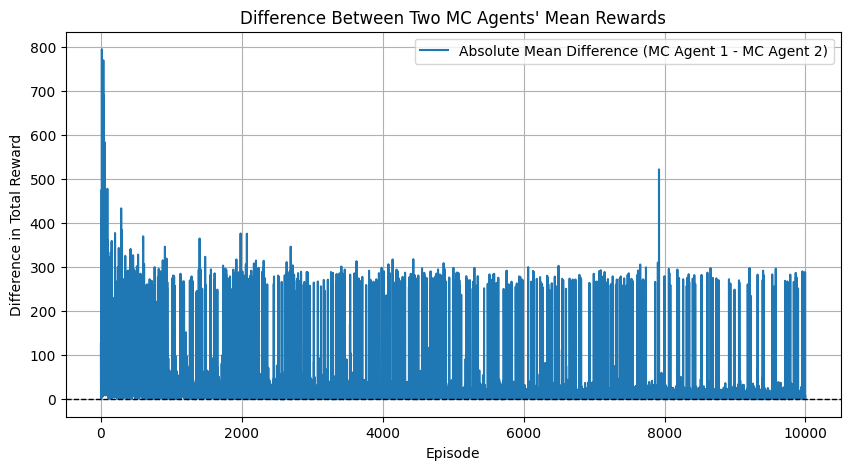

Absolute difference in mean reward between 2 different Multi MC-learning runs with num_replications= 5


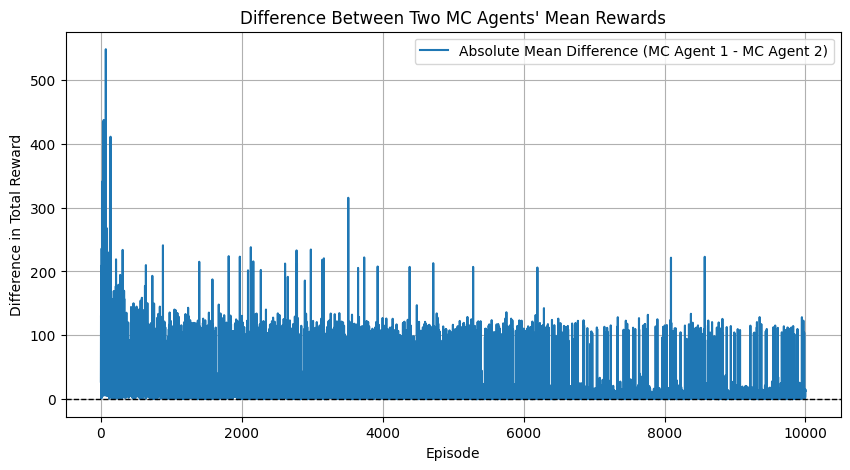

Absolute difference in mean reward between 2 different Multi MC-learning runs with num_replications= 10


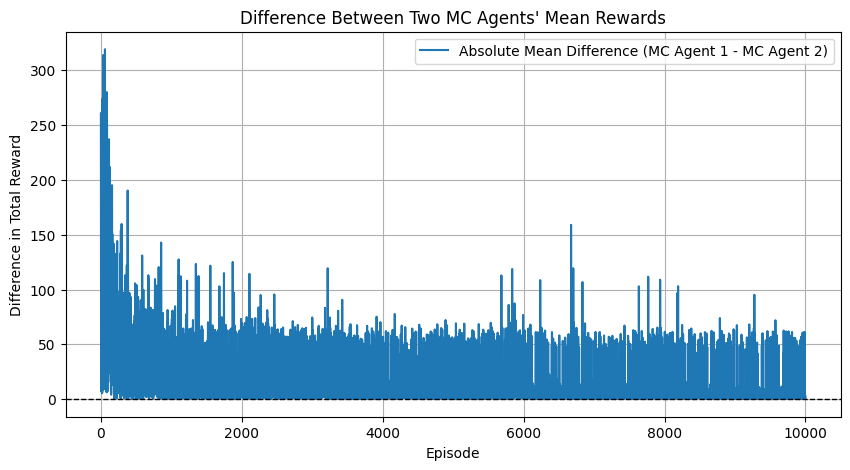

Absolute difference in mean reward between 2 different Multi MC-learning runs with num_replications= 15


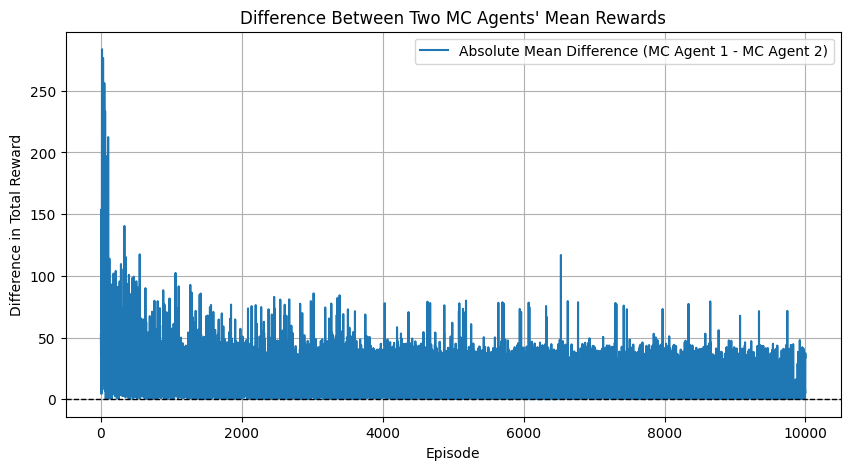

Absolute difference in mean reward between 2 different Multi MC-learning runs with num_replications= 20


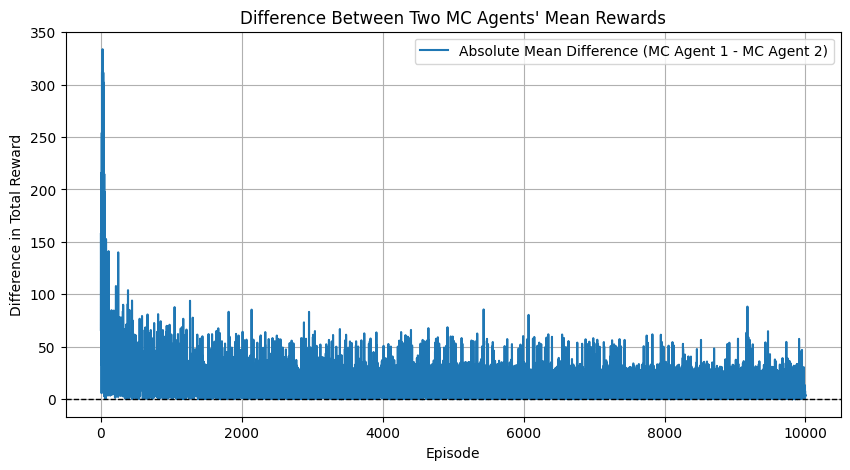

In [248]:
chosen_replications = [2, 5, 10, 15, 20]
max_diff = np.zeros(len(chosen_replications)) #store the max difference in mean rewards for every two agents with the same num_run
for idx, num_run in enumerate(chosen_replications):
    all_rewards = np.zeros((2, num_run, n))
    mean_rewards = np.zeros((2, n))
    for a in range(2): #I will try with two different agents, trained on the same num_run
        for r in range(num_run):
            agent = MC_agent()
            _, _, total_rewards = agent.solve(maze)
            all_rewards[a, r] = total_rewards
            
        mean_rewards[a] = np.mean(all_rewards[a], axis=0)
    
    mean_difference = abs(mean_rewards[0] - mean_rewards[1])
    max_diff[idx] = np.max(mean_difference[-100:]) #of the last few episodes, because the first ones are usually random/agent is still learning
    print("Absolute difference in mean reward between 2 different Multi MC-learning runs with num_replications=", num_run);
    plot_diff(mean_difference)

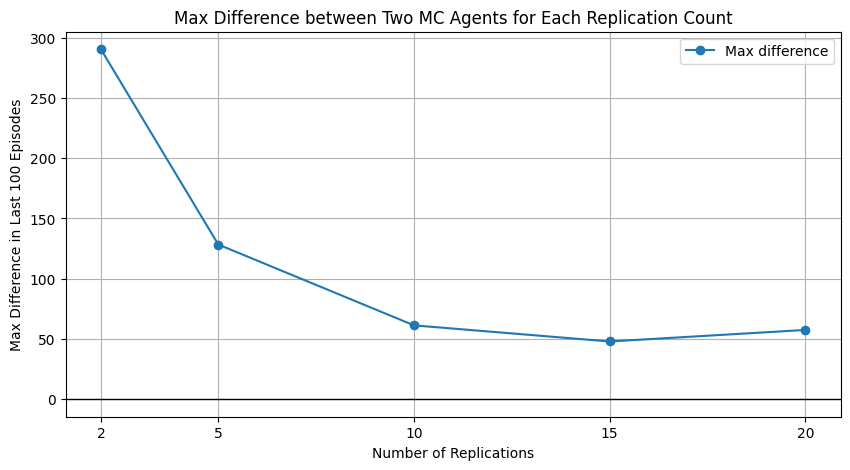

In [252]:
#plot max differences for every num_run
plt.figure(figsize=(10,5))
plt.plot(chosen_replications, max_diff, marker='o', label="Max difference") 
plt.axhline(0, color='black', linewidth=1) 
plt.xlabel("Number of Replications")
plt.ylabel("Max Difference in Last 100 Episodes")
plt.title("Max Difference between Two MC Agents for Each Replication Count")
plt.xticks(chosen_replications)
plt.legend()
plt.grid(True)
plt.show()

In [253]:
#chosen value
num_replications = 10

Learning Curves

In [255]:
#learning curve
all_rewards = []

for r in range(num_replications):
    agent = MC_agent()
    _, _, total_rewards = agent.solve(maze)
    all_rewards.append(total_rewards)

#join different 
mean_rewards = np.mean(all_rewards, axis=0)
std_rewards = np.std(all_rewards, axis=0)

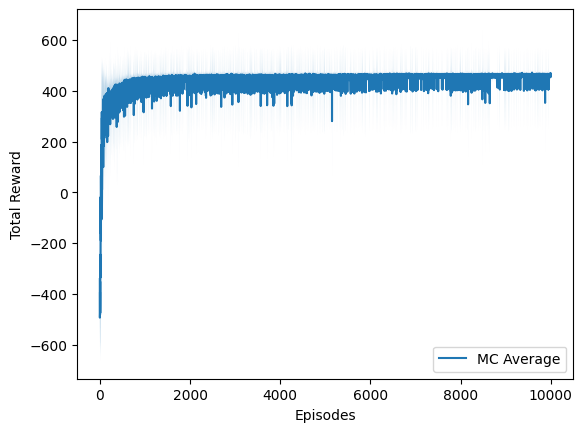

In [256]:
plot_lc(mean_rewards, std_rewards)

In [257]:
np.max(mean_rewards)

np.float64(471.9)

Effect of gamma and epsilon

In [140]:
epsilons = [0, 0.01, 0.1, 0.5, 1]
gammas = [0, 0.1, 0.5, 0.9, 1]

In [144]:
results = np.zeros((len(epsilons), len(gammas)))

Q = np.random.rand(maze.get_state_size(), maze.get_action_size())
V = np.zeros(maze.get_state_size())
policy = np.ones((maze.get_state_size(), maze.get_action_size())) / 4
values = [V]
total_rewards = []
n = 10000

replications = 10

for i, epsilon in enumerate(epsilons):
    for j, gamma in enumerate(gammas):

        performances = []

        for r in range(replications):
            agent = MC_agent()

            policy, values, total_rewards = agent.every_visit_MC(maze, Q, V, policy, values, total_rewards, n, 0.01, epsilon, gamma)

            performance = np.mean(total_rewards[-1000:])
            performances.append(performance)

        results[i, j] = np.mean(performances)

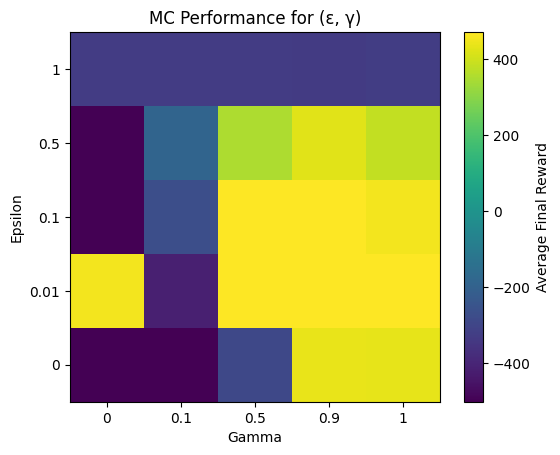

In [145]:
plt.imshow(results, cmap='viridis', origin='lower')
plt.colorbar(label="Average Final Reward")

plt.xticks(range(len(gammas)), gammas)
plt.yticks(range(len(epsilons)), epsilons)

plt.xlabel("Gamma")
plt.ylabel("Epsilon")
plt.title("MC Performance for (ε, γ)")

plt.show()

Results of the MC agent:



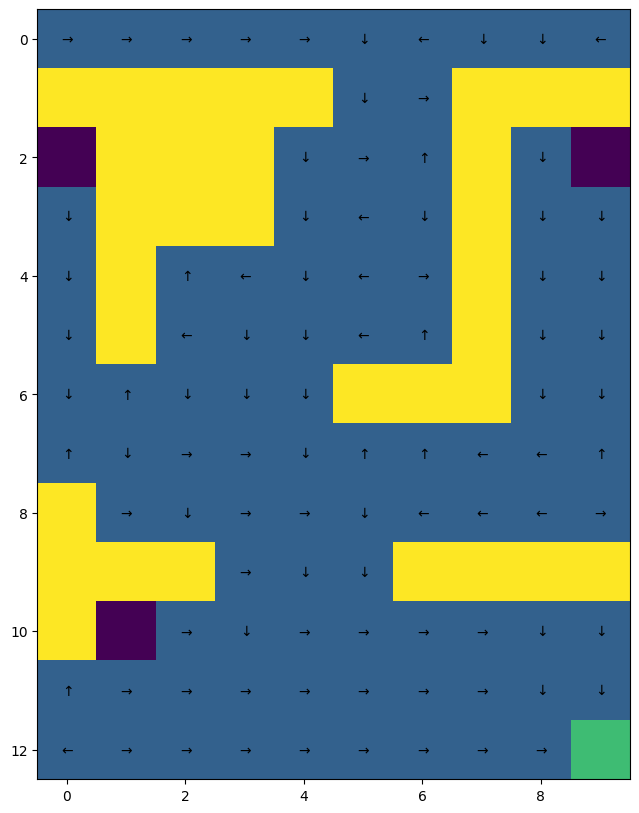

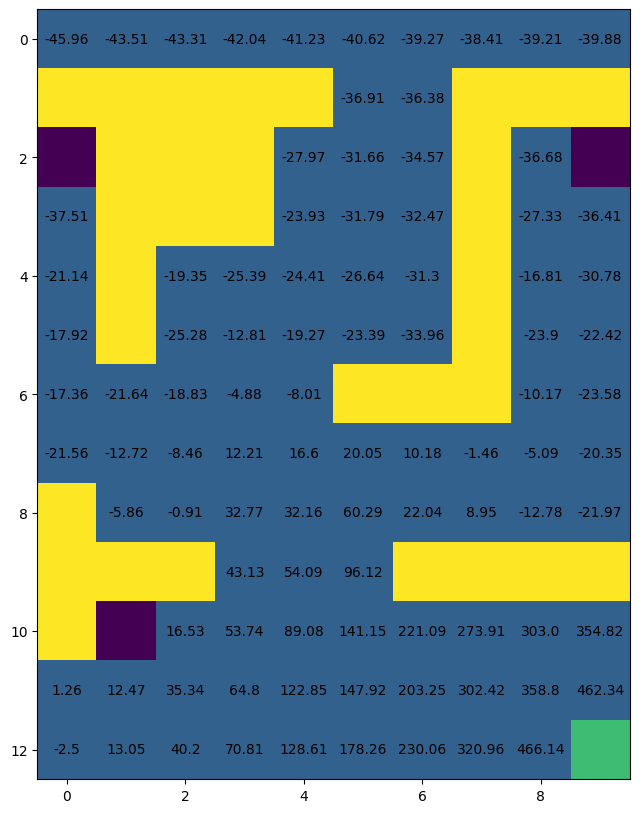

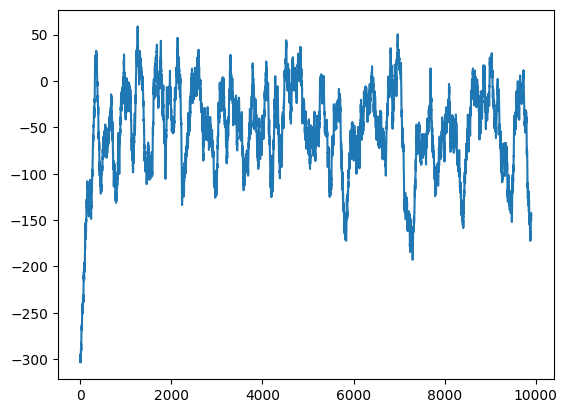

In [264]:
#MC with epsilon = 0.9
#I will do it with one run MC (without loss of generalizability)

Q = np.random.rand(maze.get_state_size(), maze.get_action_size())
V = np.zeros(maze.get_state_size())
policy = np.ones((maze.get_state_size(), maze.get_action_size())) / 4
values = [V]
total_rewards = []


n = 10000 
alpha = 0.01 
epsilon = 0.9
gamma = 0.98

mc_agent = MC_agent()
mc_policy, mc_values, total_rewards = mc_agent.every_visit_MC(maze, Q, V, policy, values, total_rewards, n, alpha, epsilon, gamma)

print("Results of the MC agent:\n")
maze.get_graphics().draw_policy(mc_policy)
maze.get_graphics().draw_value(mc_values[-1])

window = 100
smoothed = np.convolve(total_rewards,
                       np.ones(window)/window,
                       mode='valid')
plt.plot(smoothed)

Results of the MC agent:



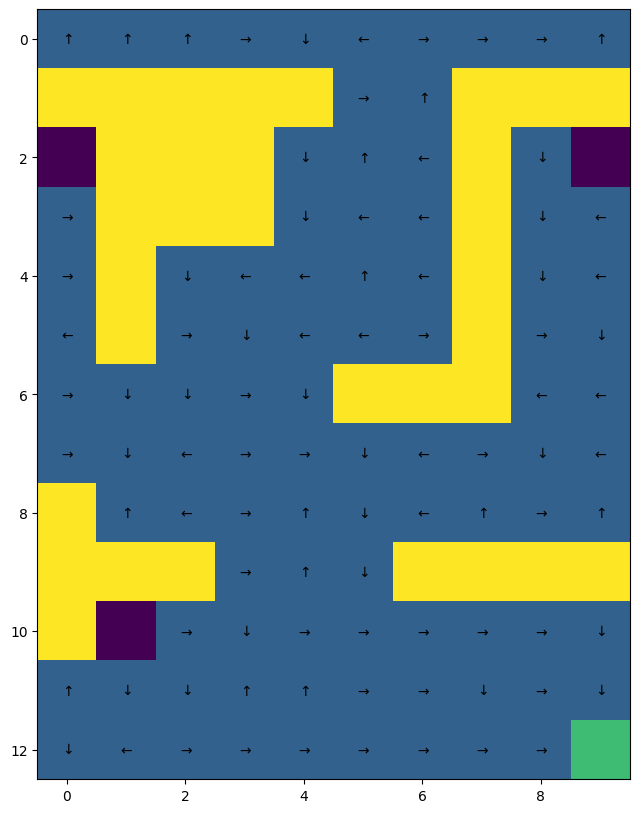

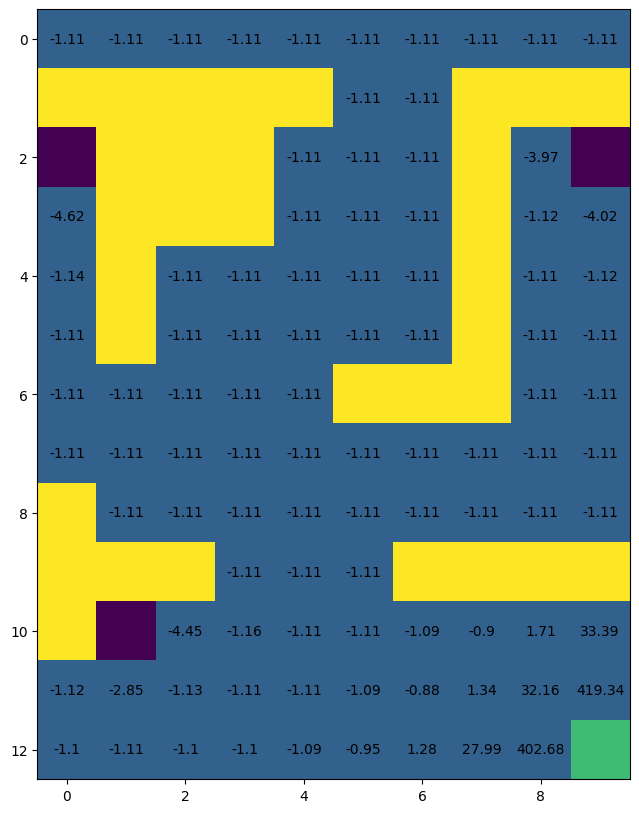

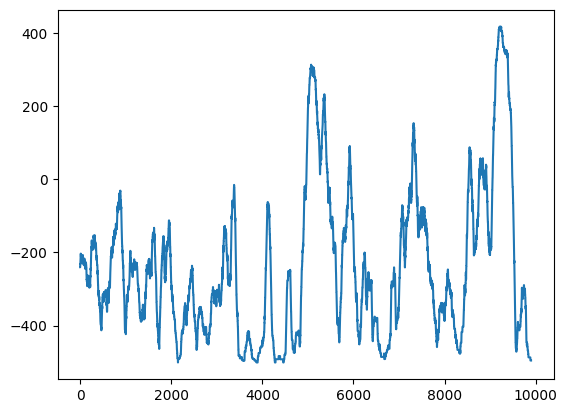

In [265]:
#MC with gamma = 0.1

Q = np.random.rand(maze.get_state_size(), maze.get_action_size())
V = np.zeros(maze.get_state_size())
policy = np.ones((maze.get_state_size(), maze.get_action_size())) / 4
values = [V]
total_rewards = []


n = 10000 
alpha = 0.01 
epsilon = 0.1
gamma = 0.1

mc_agent = MC_agent()
mc_policy, mc_values, total_rewards = mc_agent.every_visit_MC(maze, Q, V, policy, values, total_rewards, n, alpha, epsilon, gamma)

print("Results of the MC agent:\n")
maze.get_graphics().draw_policy(mc_policy)
maze.get_graphics().draw_value(mc_values[-1])

window = 100
smoothed = np.convolve(total_rewards,
                       np.ones(window)/window,
                       mode='valid')
plt.plot(smoothed)

Results of the MC agent:



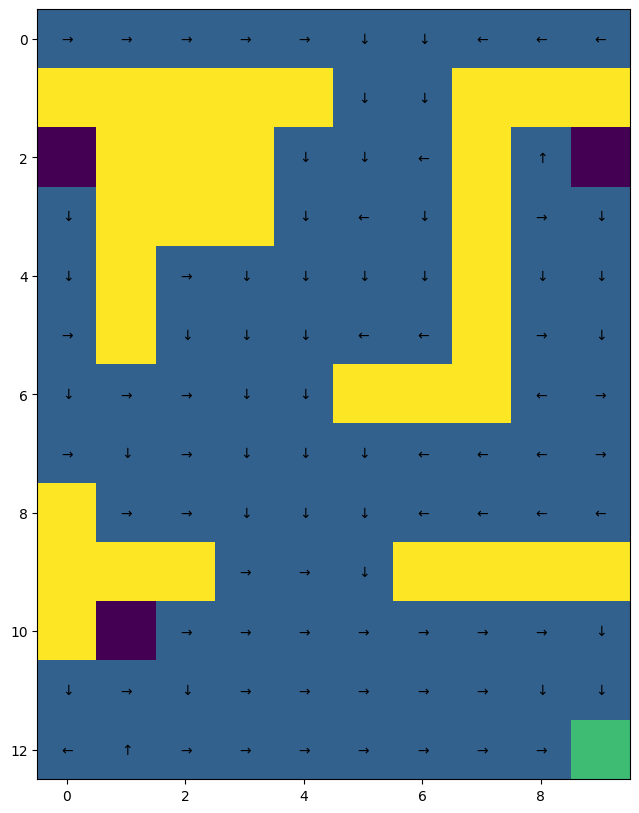

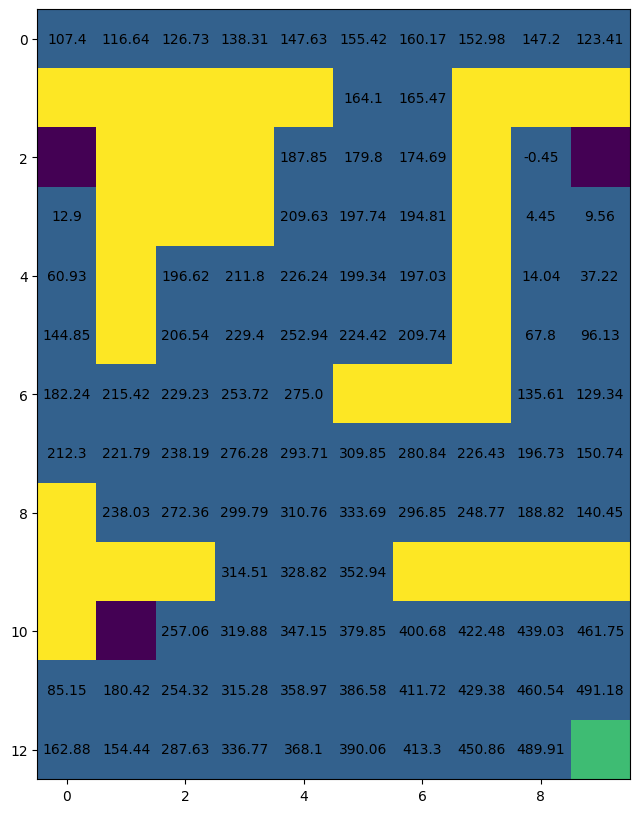

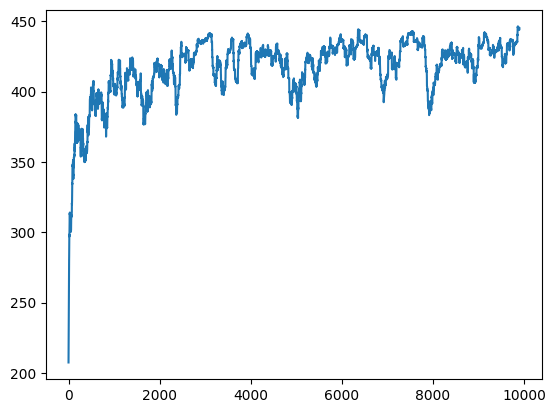

In [269]:
#epsilon = 0.5

Q = np.random.rand(maze.get_state_size(), maze.get_action_size())
V = np.zeros(maze.get_state_size())
policy = np.ones((maze.get_state_size(), maze.get_action_size())) / 4
values = [V]
total_rewards = []


n = 10000 
alpha = 0.01 
epsilon = 0.5
gamma = 0.98

mc_agent = MC_agent()
mc_policy, mc_values, total_rewards = mc_agent.every_visit_MC(maze, Q, V, policy, values, total_rewards, n, alpha, epsilon, gamma)

print("Results of the MC agent:\n")
maze.get_graphics().draw_policy(mc_policy)
maze.get_graphics().draw_value(mc_values[-1])

window = 100
smoothed = np.convolve(total_rewards,
                       np.ones(window)/window,
                       mode='valid')
plt.plot(smoothed)

## TD agent

In [331]:
# This class define the Temporal-Difference agent

class TD_agent(object):
    
    # [Action required]
    # WARNING: make sure this function can be called by the auto-marking script

    def getEpsGreedyPolicy(self, Q, s, epsilon):
        max_q_a = int(np.argmax(Q[s]))
        return [(epsilon/4 if (i != max_q_a) else (1 - epsilon + epsilon/4)) for i in range (4)]
        
    def sarsa(self, env, Q, V, policy, values, total_rewards, n, alpha, epsilon):
        num_states = env.get_state_size()
        num_actions = env.get_action_size();
        gamma = env.get_gamma()

        for i in range(n):
            t, state_curr, reward, done = env.reset(); #state_curr is s, reward is r
            policy[state_curr] = self.getEpsGreedyPolicy(Q, state_curr, epsilon)
            action_curr = np.random.choice(4, p=policy[state_curr]) #action_curr is a
            G = reward
            
            while not done:
                t, state_next, reward, done = env.step(action_curr); #state_next is s'
                G += reward

                if done:
                    Q[state_curr][action_curr] += alpha * (reward - Q[state_curr][action_curr])
                    break
                                    
                policy[state_next] = self.getEpsGreedyPolicy(Q, state_next, epsilon)
                action_next = np.random.choice(4, p=policy[state_next]) #action_next is a'
                Q[state_curr][action_curr] += alpha*(reward + gamma*Q[state_next][action_next] - Q[state_curr][action_curr])
                state_curr, action_curr = state_next, action_next


            values.append(np.sum(Q * policy, axis=1).copy())
            total_rewards.append(G)
                
        return policy, values, total_rewards

    def solve(self, env):
        """
        Solve a given Maze environment using Temporal Difference learning
        input: env {Maze object} -- Maze to solve
        output:
          - policy {np.array} -- Optimal policy found to solve the given Maze environment
          - values {list of np.array} -- List of successive value functions for each episode
          - total_rewards {list of float} -- Corresponding list of successive total non-discounted sum of reward for each episode
        """
        
        # Initialisation (can be edited)
        Q = np.random.rand(env.get_state_size(), env.get_action_size())
        V = np.zeros(env.get_state_size())
        policy = np.ones((env.get_state_size(), env.get_action_size())) / 4
        values = [V]
        total_rewards = []
        
        ####
        # Add your code here
        # WARNING: this agent only has access to env.reset() and env.step()
        # You should not use env.get_T(), env.get_R() or env.get_absorbing() to compute any value
        ####
    
        n = 10000
        alpha = 0.25
        epsilon = 0.1
        
        policy, values, total_rewards = self.sarsa(env, Q, V, policy, values, total_rewards, n, alpha, epsilon)
        
        return policy, values, total_rewards

Results of the TD agent:



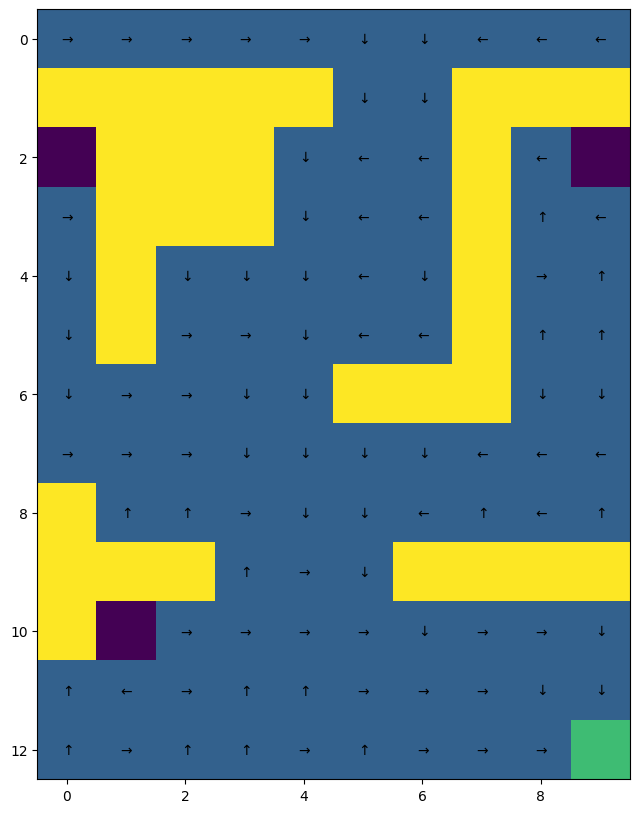

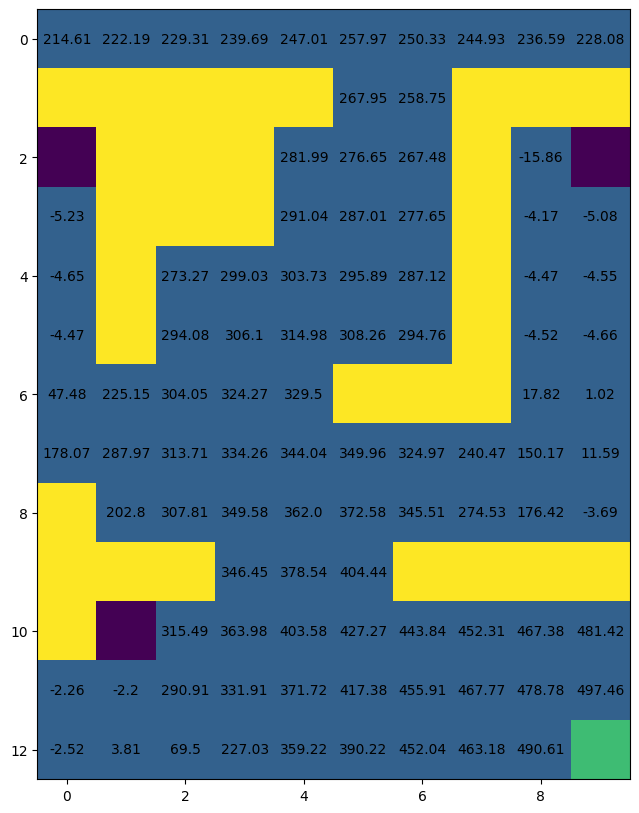

In [336]:
td_agent = TD_agent()
td_policy, td_values, td_total_rewards = td_agent.solve(maze)

print("Results of the TD agent:\n")
maze.get_graphics().draw_policy(td_policy)
maze.get_graphics().draw_value(td_values[-1])

Results of the TD agent:



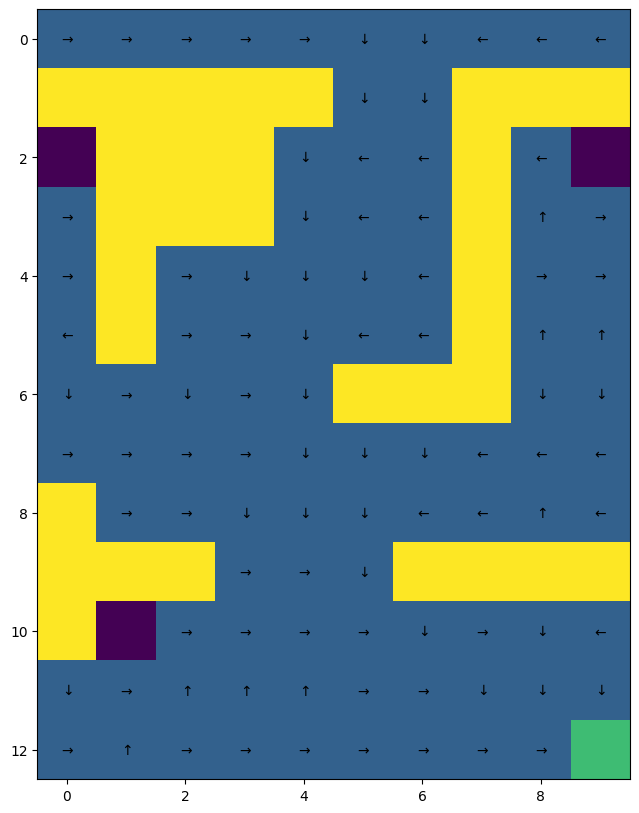

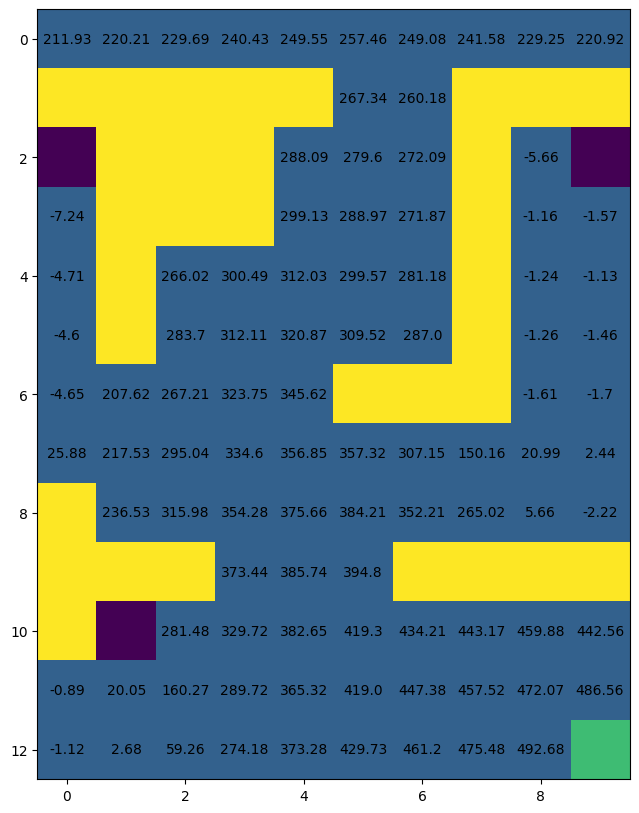

In [326]:
td_agent2 = TD_agent()
td_policy2, td_values2, td_total_rewards2 = td_agent.solve(maze)

print("Results of the TD agent:\n")
maze.get_graphics().draw_policy(td_policy2)
maze.get_graphics().draw_value(td_values2[-1])

Learning Curve

In [337]:
def plot_lc(mean_rewards, std_rewards):
    plt.plot(mean_rewards)

    plt.fill_between(
        range(n),
        mean_rewards - std_rewards,
        mean_rewards + std_rewards,
        alpha=0.3
    )
    
    plt.xlabel("Episodes")
    plt.ylabel("Total Reward")
    plt.title("Learning Curve for SARSA(0)")
    plt.legend()
    plt.show()
    

In [338]:
#learning curve
all_rewards = []

for r in range(num_replications):
    agent = MC_agent()
    _, _, total_rewards = agent.solve(maze)
    all_rewards.append(total_rewards)

#join different 
mean_rewards = np.mean(all_rewards, axis=0)
std_rewards = np.std(all_rewards, axis=0)

/var/folders/_2/w9cvr2ln7kg4nvsf8cvr38zh0000gn/T/ipykernel_51444/811424675.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


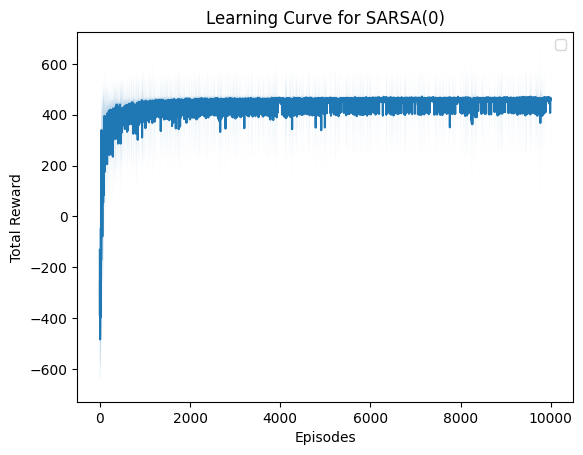

In [339]:
plot_lc(mean_rewards, std_rewards)

Exploring different values of alpha and epsilon

Results of the TD agent:



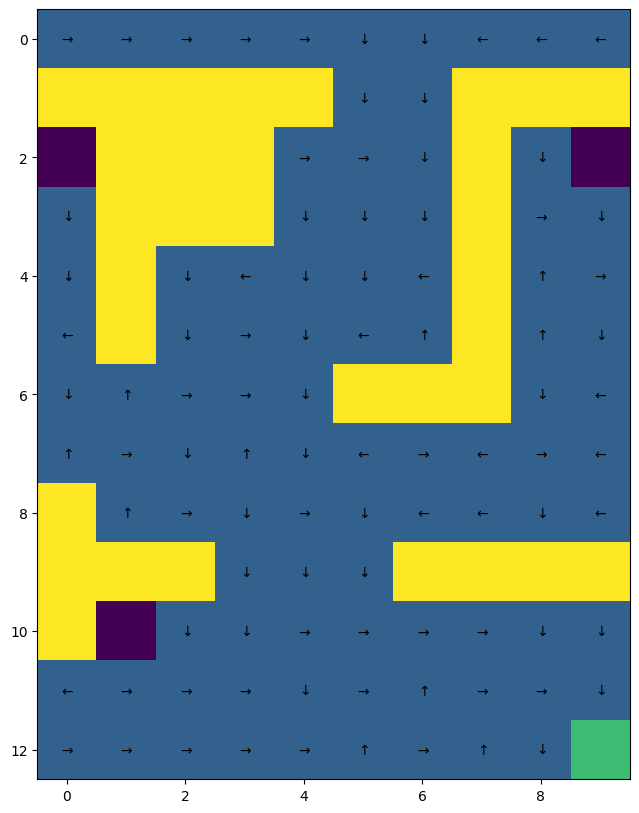

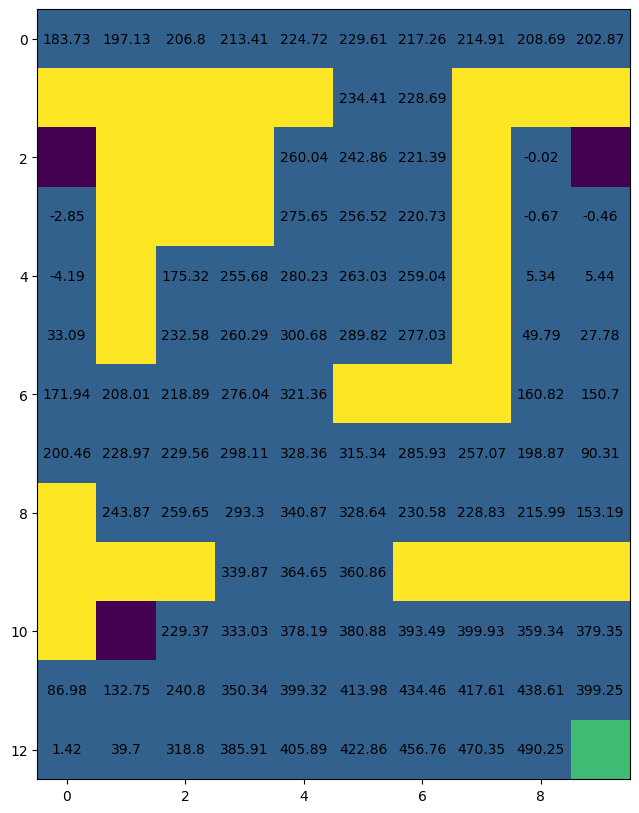

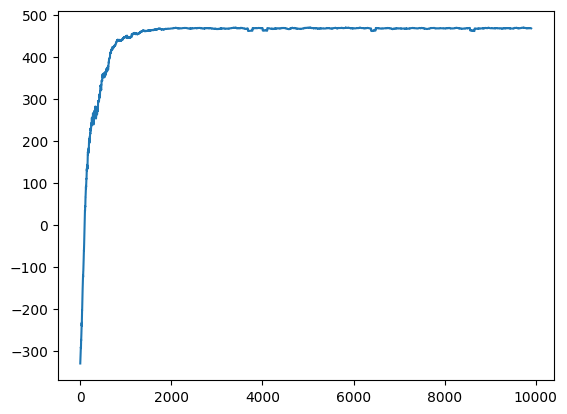

In [340]:
Q = np.random.rand(maze.get_state_size(), maze.get_action_size())
V = np.zeros(maze.get_state_size())
policy = np.ones((maze.get_state_size(), maze.get_action_size())) / 4
values = [V]
total_rewards = []


n = 10000 
alpha = 0.01 
epsilon = 0.1
gamma = 0.1

td_agent = TD_agent()
td_policy, td_values, total_rewards = td_agent.sarsa(maze, Q, V, policy, values, total_rewards, n, alpha, epsilon)

print("Results of the TD agent:\n")
maze.get_graphics().draw_policy(mc_policy)
maze.get_graphics().draw_value(mc_values[-1])

window = 100
smoothed = np.convolve(total_rewards,
                       np.ones(window)/window,
                       mode='valid')
plt.plot(smoothed)

Results of the TD agent:



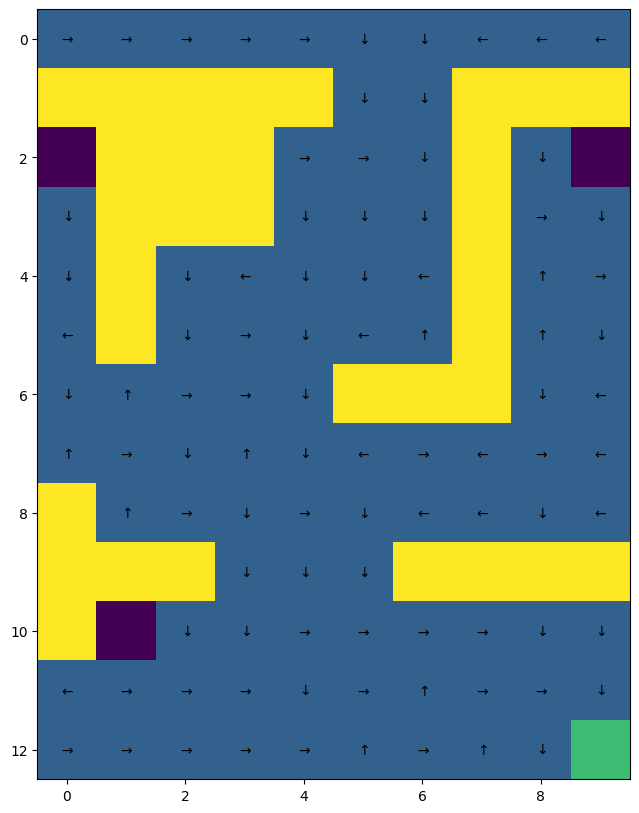

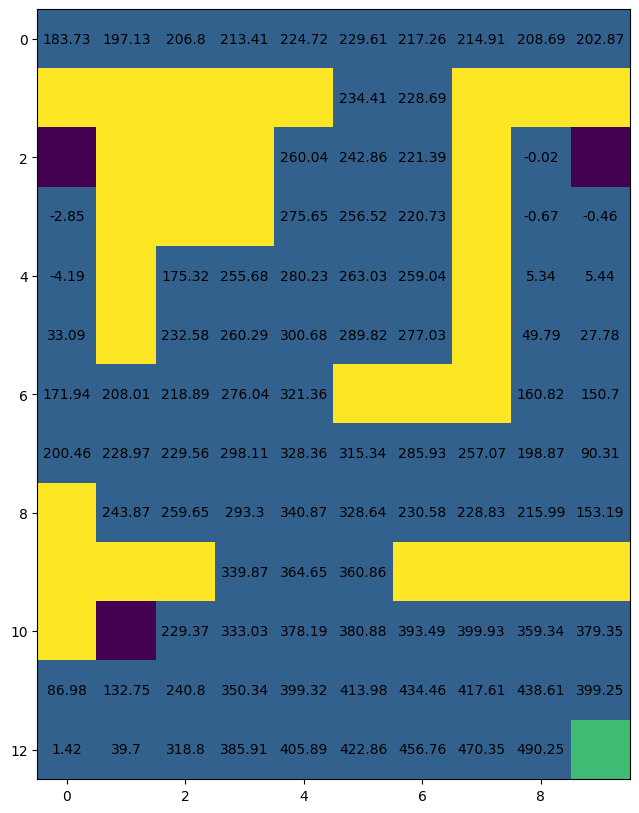

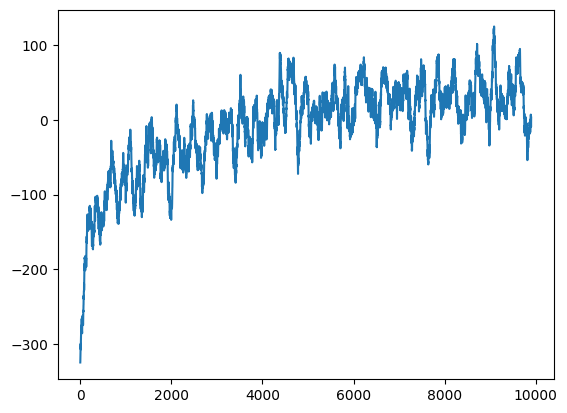

In [341]:
#TD with epsilon = 0.9

Q = np.random.rand(maze.get_state_size(), maze.get_action_size())
V = np.zeros(maze.get_state_size())
policy = np.ones((maze.get_state_size(), maze.get_action_size())) / 4
values = [V]
total_rewards = []


n = 10000 
alpha = 0.01 
epsilon = 0.9
gamma = 0.1

td_agent = TD_agent()
td_policy, td_values, total_rewards = td_agent.sarsa(maze, Q, V, policy, values, total_rewards, n, alpha, epsilon)

print("Results of the TD agent:\n")
maze.get_graphics().draw_policy(mc_policy)
maze.get_graphics().draw_value(mc_values[-1])

window = 100
smoothed = np.convolve(total_rewards,
                       np.ones(window)/window,
                       mode='valid')
plt.plot(smoothed)

Results of the TD agent:



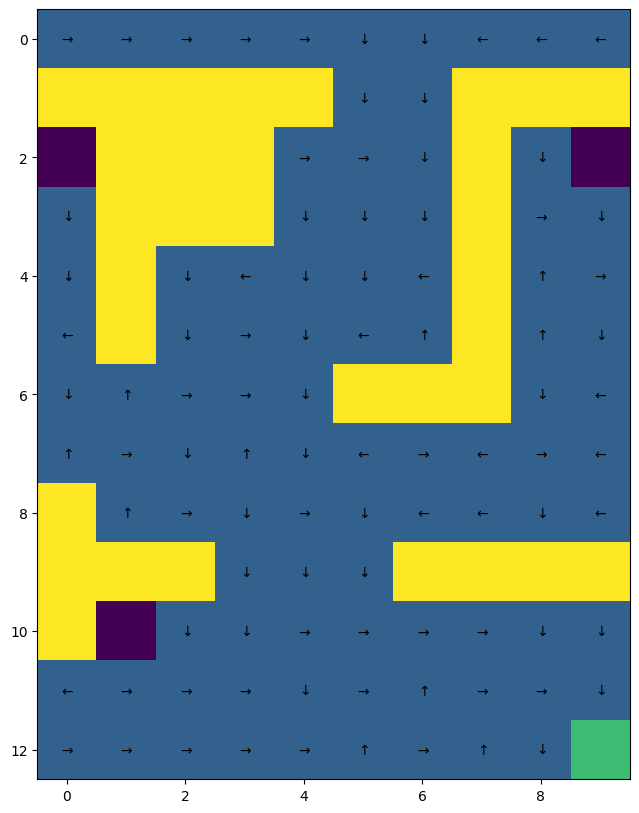

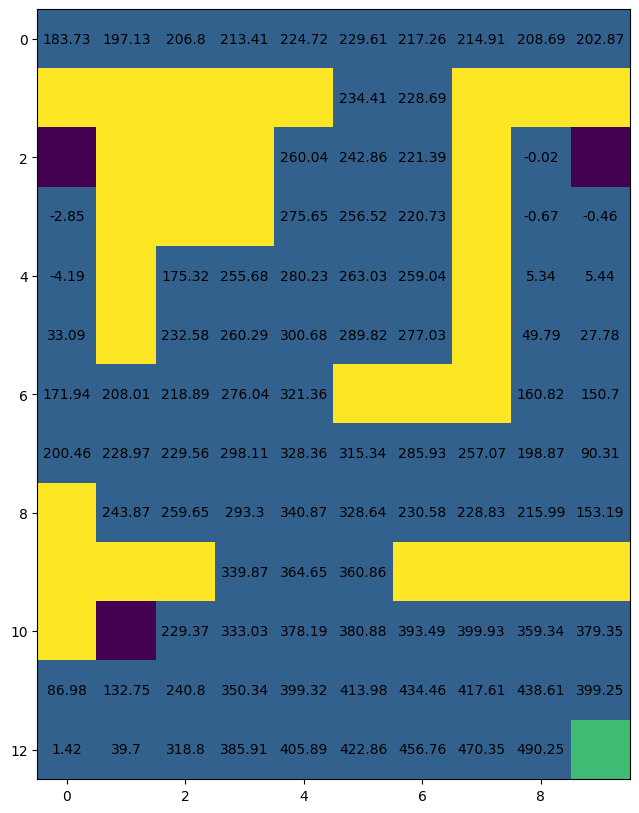

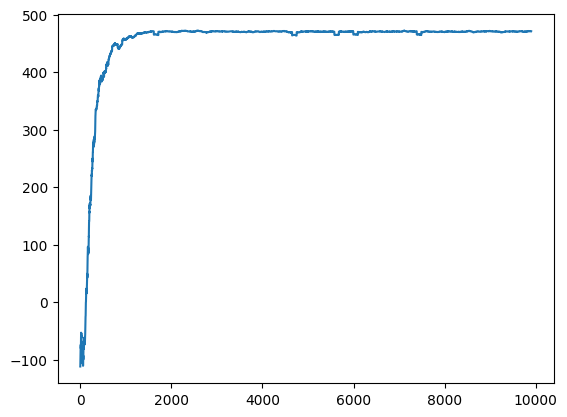

In [342]:
#TD with epsilon = 0

Q = np.random.rand(maze.get_state_size(), maze.get_action_size())
V = np.zeros(maze.get_state_size())
policy = np.ones((maze.get_state_size(), maze.get_action_size())) / 4
values = [V]
total_rewards = []


n = 10000 
alpha = 0.01 
epsilon = 0
gamma = 0.1

td_agent = TD_agent()
td_policy, td_values, total_rewards = td_agent.sarsa(maze, Q, V, policy, values, total_rewards, n, alpha, epsilon)

print("Results of the TD agent:\n")
maze.get_graphics().draw_policy(mc_policy)
maze.get_graphics().draw_value(mc_values[-1])

window = 100
smoothed = np.convolve(total_rewards,
                       np.ones(window)/window,
                       mode='valid')
plt.plot(smoothed)

Results of the TD agent:



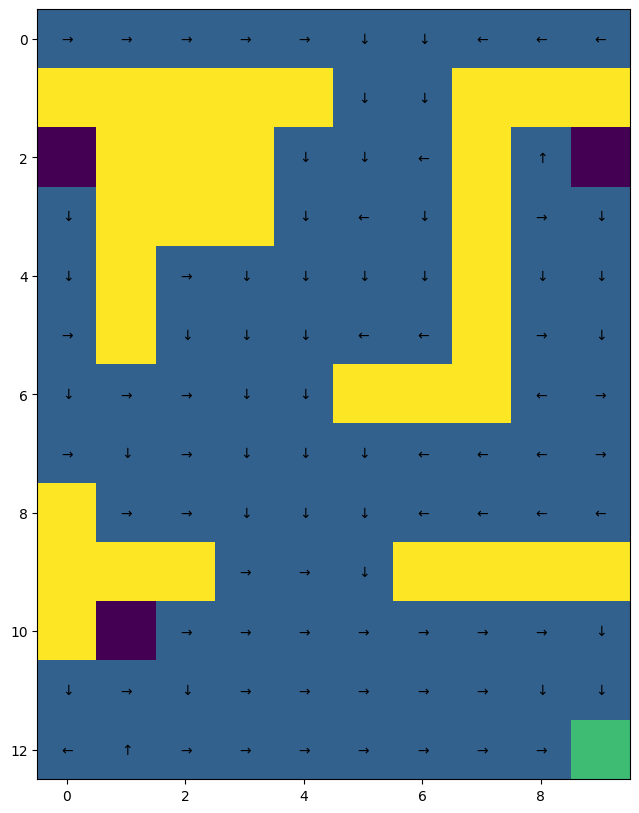

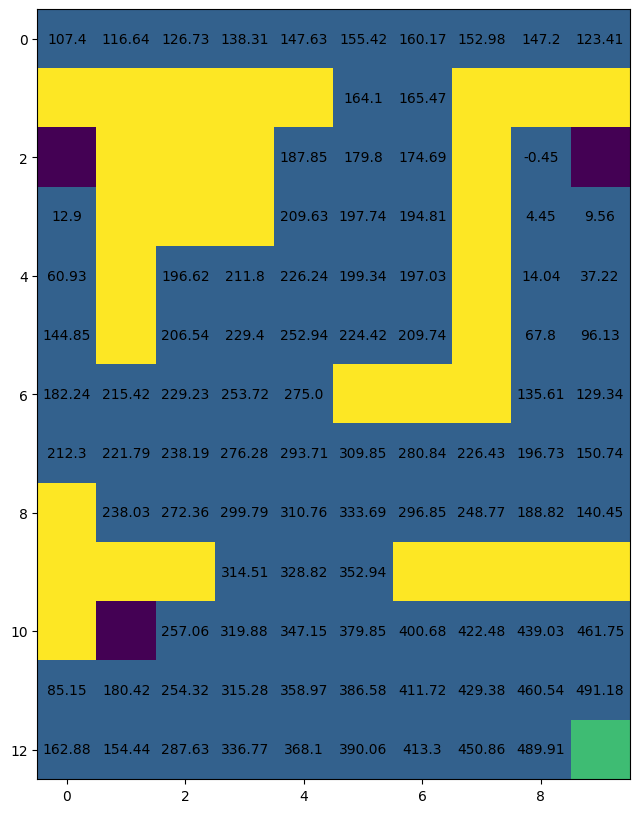

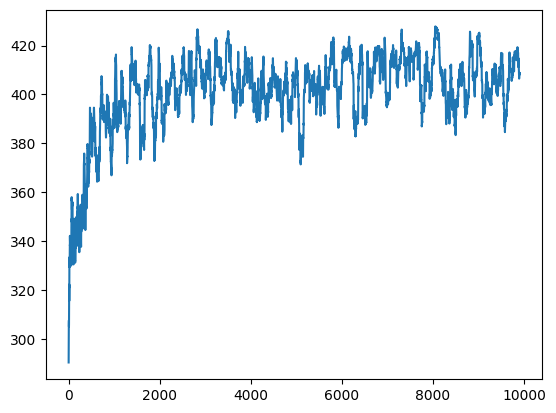

In [279]:
#TD with alpha = 0.9

Q = np.random.rand(maze.get_state_size(), maze.get_action_size())
V = np.zeros(maze.get_state_size())
policy = np.ones((maze.get_state_size(), maze.get_action_size())) / 4
values = [V]
total_rewards = []


n = 10000 
alpha = 0.9 
epsilon = 0.1
gamma = 0.1

td_agent = TD_agent()
td_policy, td_values, total_rewards = td_agent.sarsa(maze, Q, V, policy, values, total_rewards, n, alpha, epsilon)

print("Results of the TD agent:\n")
maze.get_graphics().draw_policy(mc_policy)
maze.get_graphics().draw_value(mc_values[-1])

window = 100
smoothed = np.convolve(total_rewards,
                       np.ones(window)/window,
                       mode='valid')
plt.plot(smoothed)

Results of the TD agent:



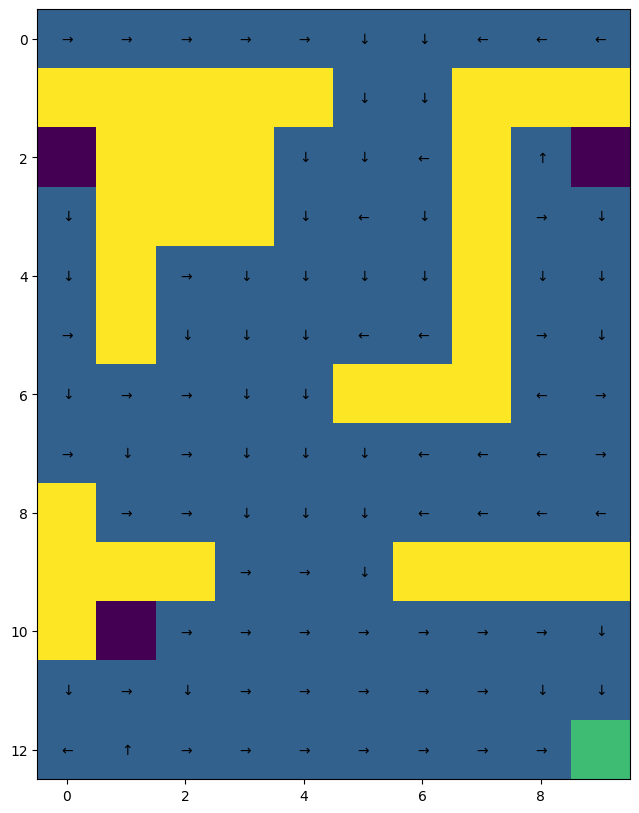

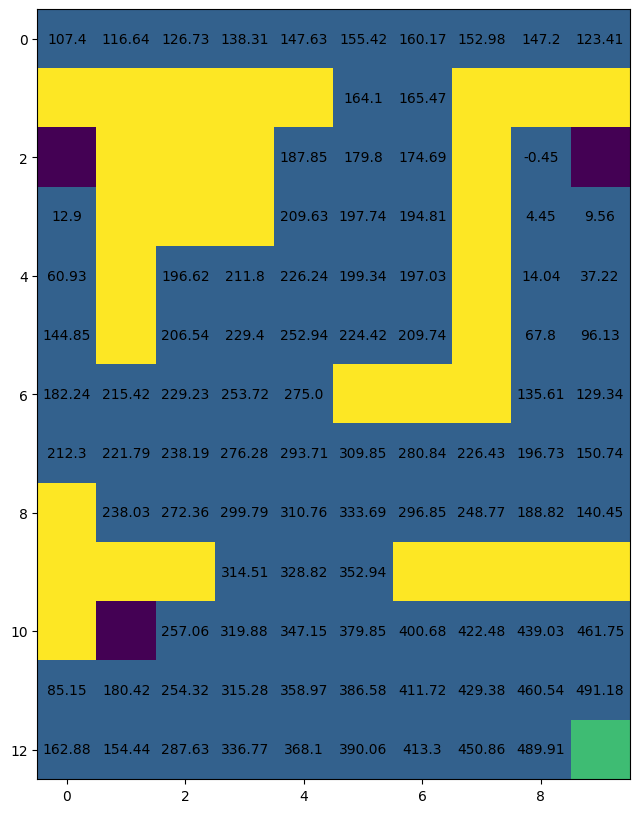

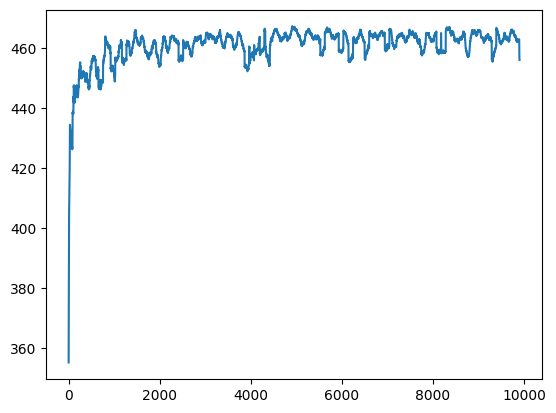

In [278]:
#TD with alpha = 0.5

Q = np.random.rand(maze.get_state_size(), maze.get_action_size())
V = np.zeros(maze.get_state_size())
policy = np.ones((maze.get_state_size(), maze.get_action_size())) / 4
values = [V]
total_rewards = []


n = 10000 
alpha = 0.5
epsilon = 0.1
gamma = 0.1

td_agent = TD_agent()
td_policy, td_values, total_rewards = td_agent.sarsa(maze, Q, V, policy, values, total_rewards, n, alpha, epsilon)

print("Results of the TD agent:\n")
maze.get_graphics().draw_policy(mc_policy)
maze.get_graphics().draw_value(mc_values[-1])

window = 100
smoothed = np.convolve(total_rewards,
                       np.ones(window)/window,
                       mode='valid')
plt.plot(smoothed)

Results of the TD agent:



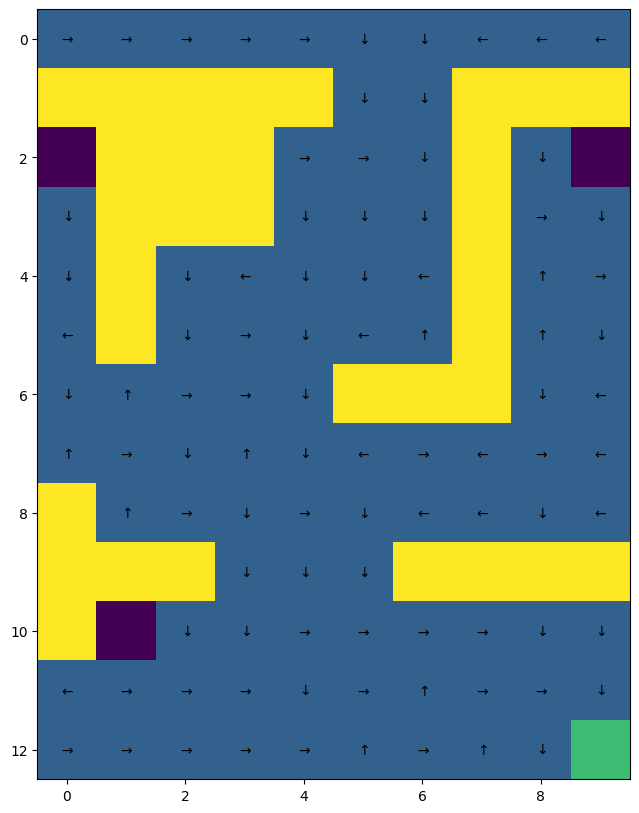

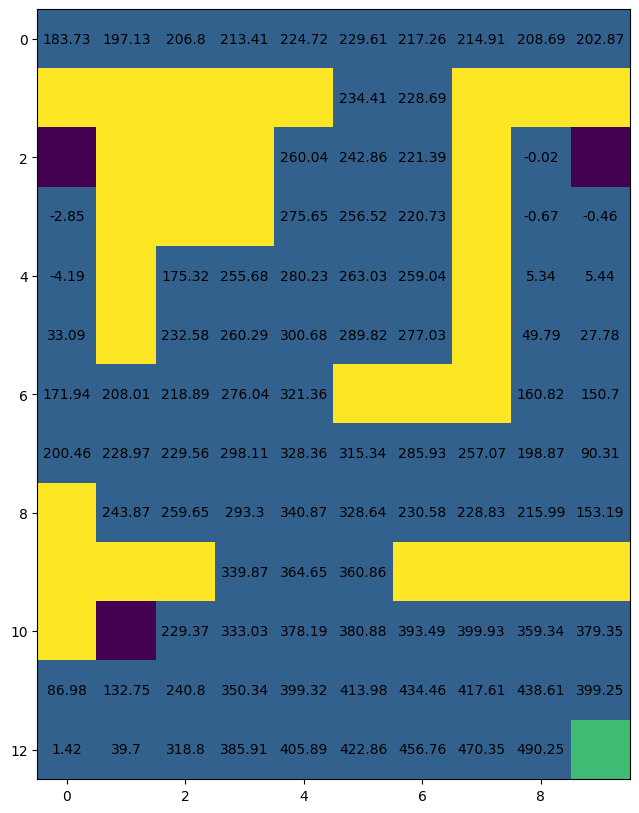

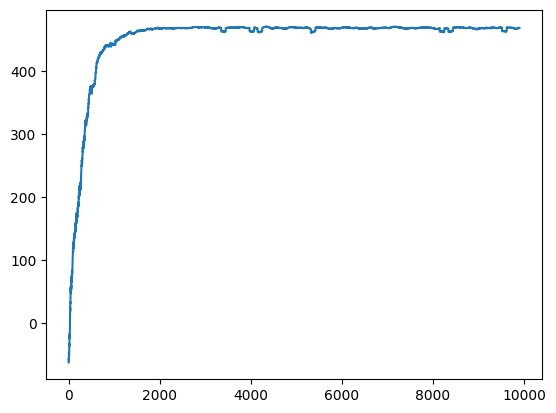

In [343]:
#TD with alpha = 0.01

Q = np.random.rand(maze.get_state_size(), maze.get_action_size())
V = np.zeros(maze.get_state_size())
policy = np.ones((maze.get_state_size(), maze.get_action_size())) / 4
values = [V]
total_rewards = []


n = 10000 
alpha = 0.01 
epsilon = 0.1
gamma = 0.1


td_agent = TD_agent()
td_policy, td_values, total_rewards = td_agent.sarsa(maze, Q, V, policy, values, total_rewards, n, alpha, epsilon)

print("Results of the TD agent:\n")
maze.get_graphics().draw_policy(mc_policy)
maze.get_graphics().draw_value(mc_values[-1])

window = 100
smoothed = np.convolve(total_rewards,
                       np.ones(window)/window,
                       mode='valid')
plt.plot(smoothed)

### Comparison Between Learners

In [313]:
#For MC
#dp_values is of shape (states)
mc_mse = np.zeros((num_replications, n)) 

for i in range(num_replications):
    mc_agent = MC_agent()
    _, mc_values, _ = mc_agent.solve(maze) #mc_values is n (episodes) x state
    for e in range(n):
        mc_mse[i, e] = mean_squared_error(dp_value, mc_values[e])

In [314]:
mc_mean_mse = np.mean(mc_mse, axis=0)  # average across runs
mc_std_mse  = np.std(mc_mse, axis=0)

In [332]:
#For TD
td_mse = np.zeros((num_replications, n)) 

for i in range(num_replications):
    td_agent = TD_agent()
    _, td_values, _ = td_agent.solve(maze) 
    for e in range(n):
        td_mse[i, e] = mean_squared_error(dp_value, td_values[e])

In [333]:
td_mean_mse = np.mean(td_mse, axis=0)
td_std_mse = np.std(td_mse, axis=0)

In [334]:
print("Final MC MSE:", mc_mean_mse[-1])
print("Final TD MSE:", td_mean_mse[-1])

Final MC MSE: 23096.033262562956
Final TD MSE: 21328.323151470966


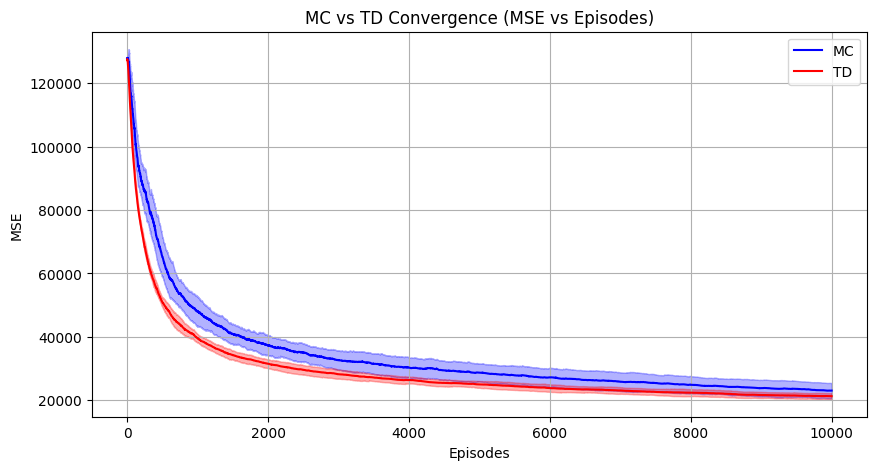

In [335]:
plt.figure(figsize=(10,5))

episodes = range(len(mc_mean_mse))

# --- MC ---
plt.plot(episodes, mc_mean_mse, label="MC", color="blue")
plt.fill_between(
    episodes,
    mc_mean_mse - mc_std_mse,
    mc_mean_mse + mc_std_mse,
    alpha=0.3,
    color="blue"
)

# --- TD ---
plt.plot(episodes, td_mean_mse, label="TD", color="red")
plt.fill_between(
    episodes,
    td_mean_mse - td_std_mse,
    td_mean_mse + td_std_mse,
    alpha=0.3,
    color="red"
)

plt.xlabel("Episodes")
plt.ylabel("MSE")
plt.title("MC vs TD Convergence (MSE vs Episodes)")
plt.legend()
plt.grid(True)
plt.show()

In [348]:
mc_agent = MC_agent()
_, mc_values, mc_total_rewards = mc_agent.solve(maze)

In [351]:
mse_mc = np.array([
    mean_squared_error(dp_value, mc_values[e])
    for e in range(n)
])

In [356]:
def plotScatter(total_rewards, mse, agent_name):
    plt.scatter(total_rewards, mse)
    plt.xlabel("Total Non-discounted Sum of Reward")
    plt.ylabel("MSE")
    plt.title(f"The estimation error for an episode against the total non-discounted sum of reward for that episode for {agent_name} learner")

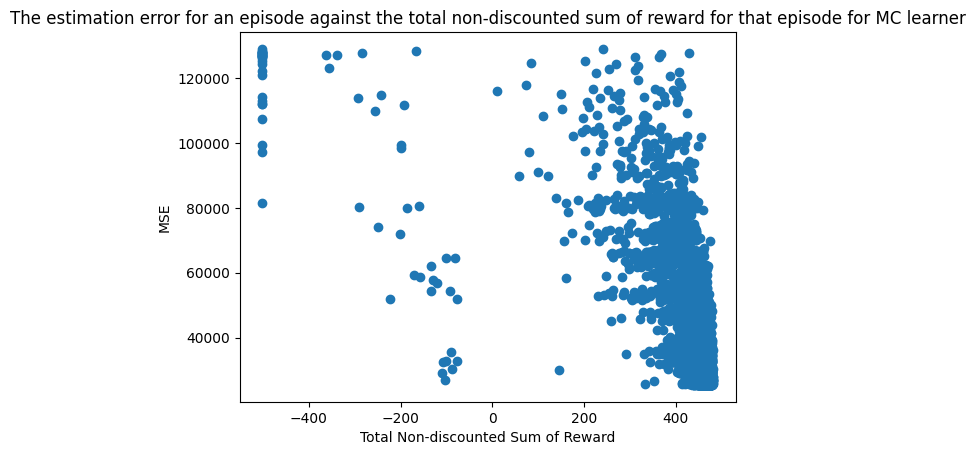

In [357]:
plotScatter(mc_total_rewards, mse_mc, "MC")

In [358]:
td_agent = TD_agent()
_, td_values, td_total_rewards = td_agent.solve(maze)

In [359]:
mse_td = np.array([
    mean_squared_error(dp_value, td_values[e])
    for e in range(n)
])

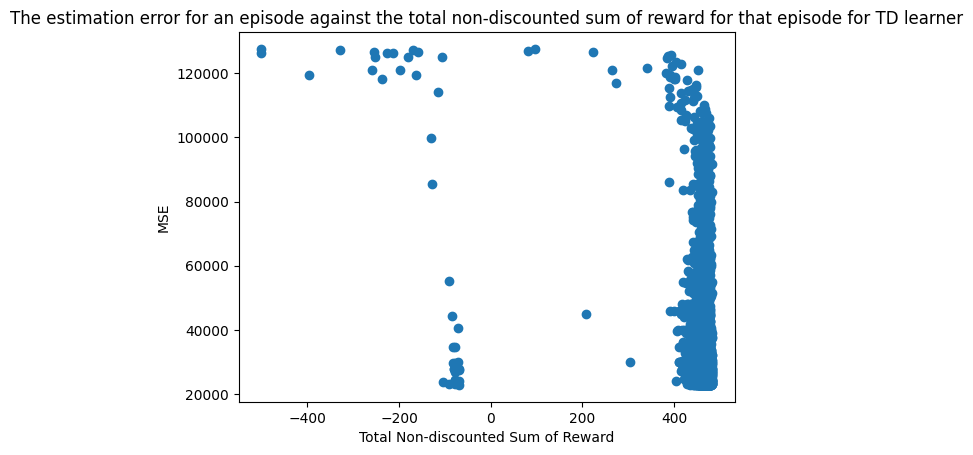

In [360]:
plotScatter(td_total_rewards, mse_td, "TD")

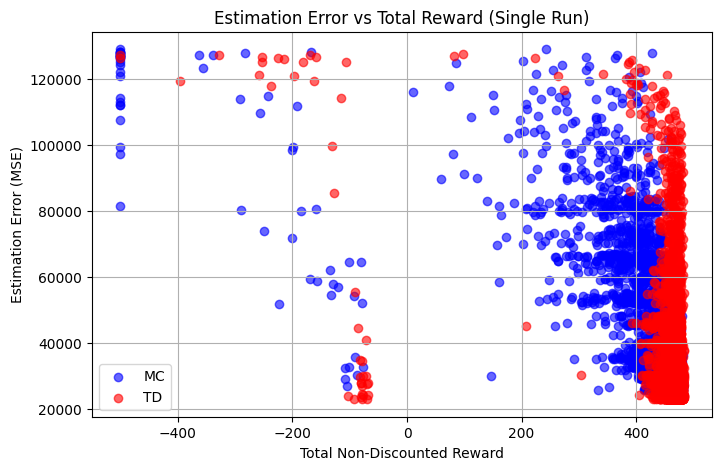

In [362]:
plt.figure(figsize=(8,5))

plt.scatter(mc_total_rewards, mse_mc, alpha=0.6, label="MC", color="blue")
plt.scatter(td_total_rewards, mse_td, alpha=0.6, label="TD", color="red")

plt.xlabel("Total Non-Discounted Reward")
plt.ylabel("Estimation Error (MSE)")
plt.title("Estimation Error vs Total Reward (Single Run)")
plt.legend()
plt.grid(True)
plt.show()

## Example main

Creating the Maze:



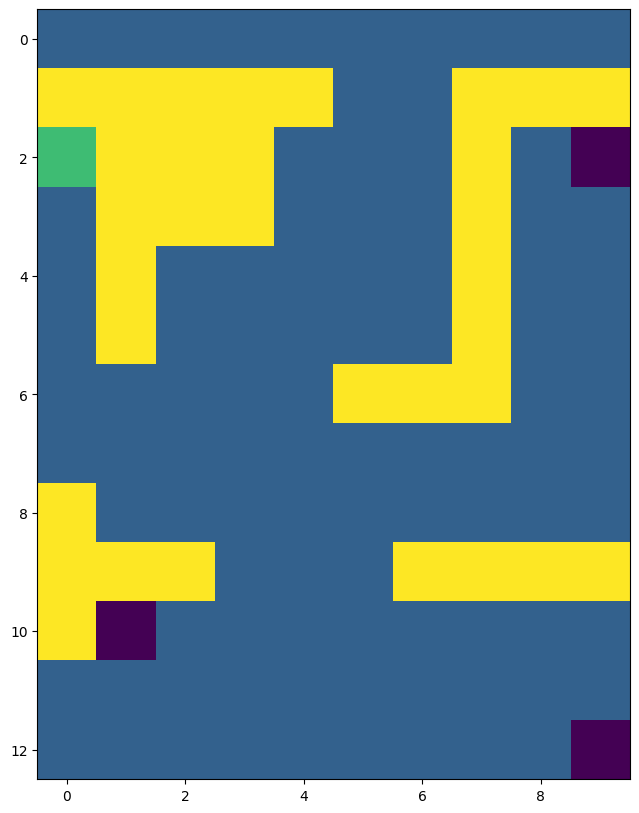

Results of the DP agent:



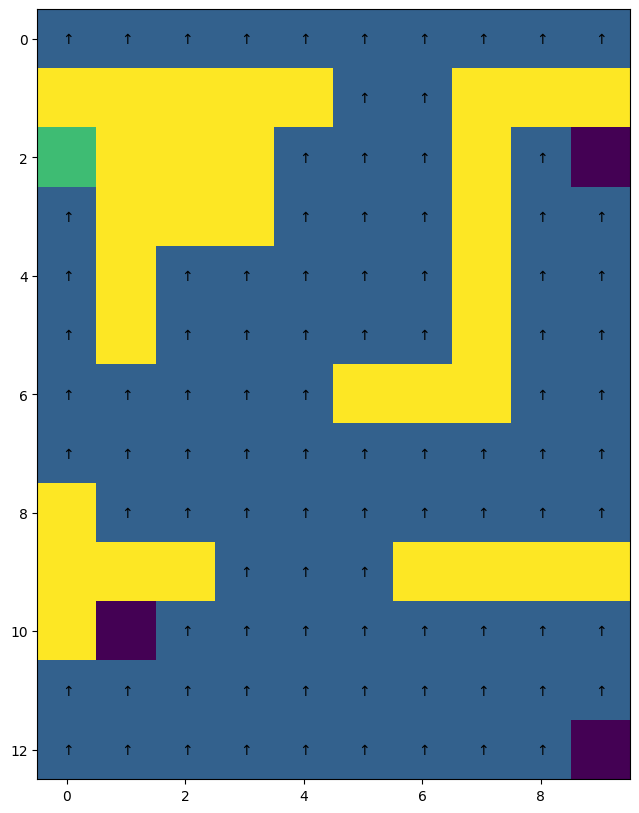

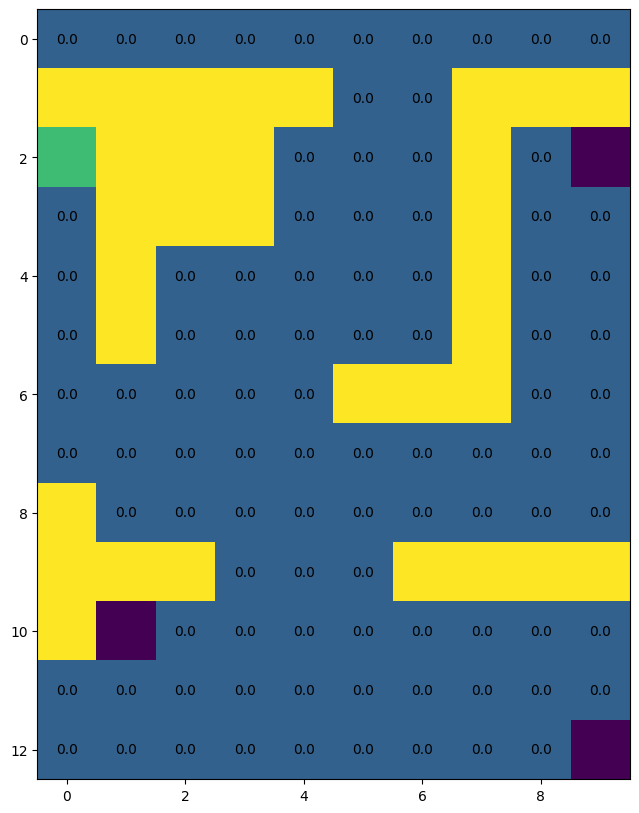

Results of the MC agent:



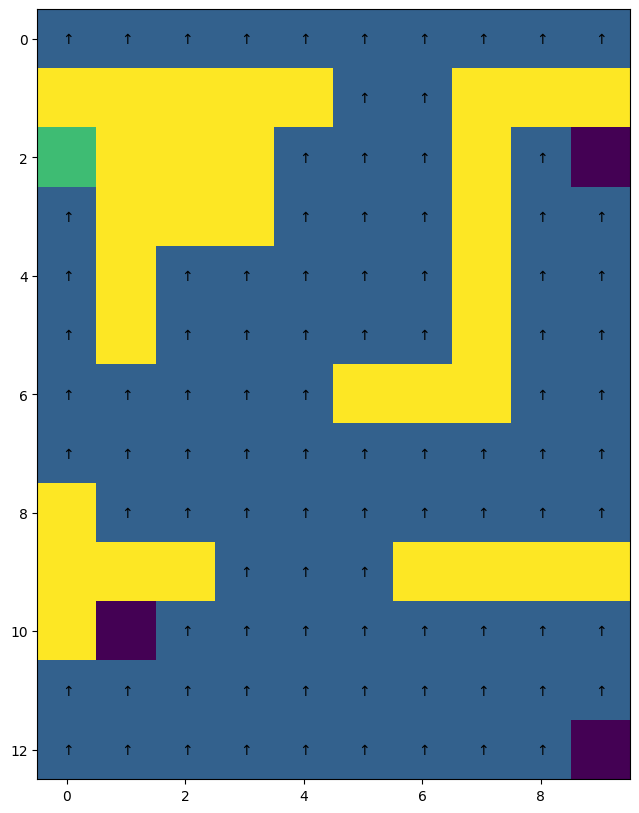

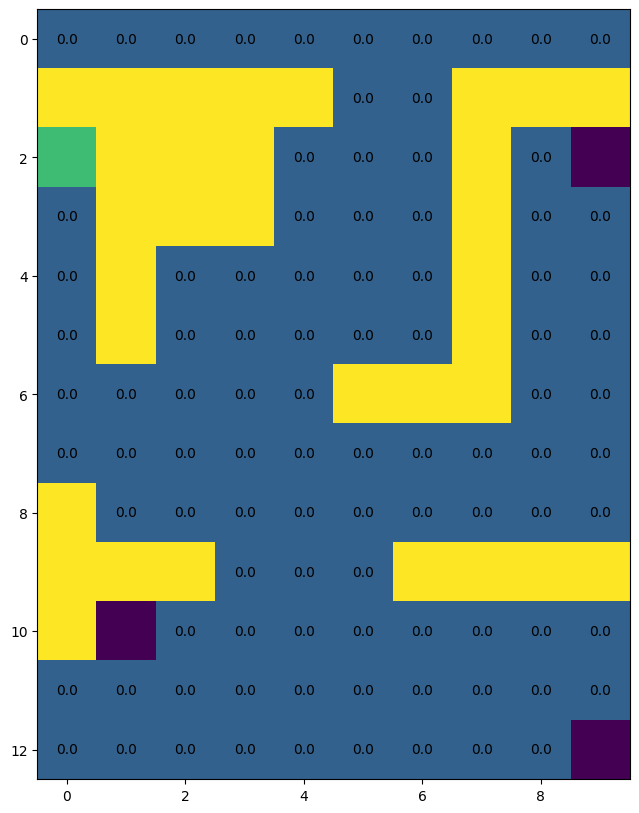

Results of the TD agent:



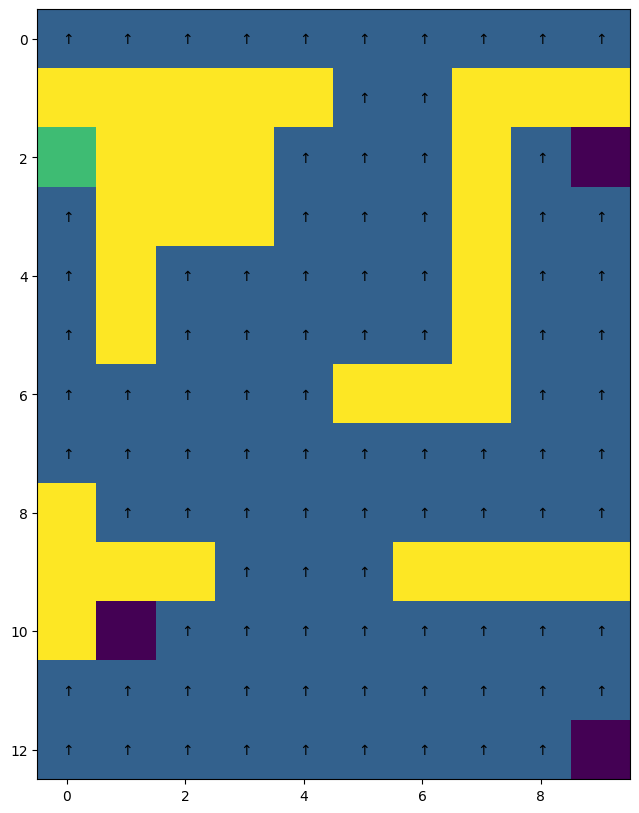

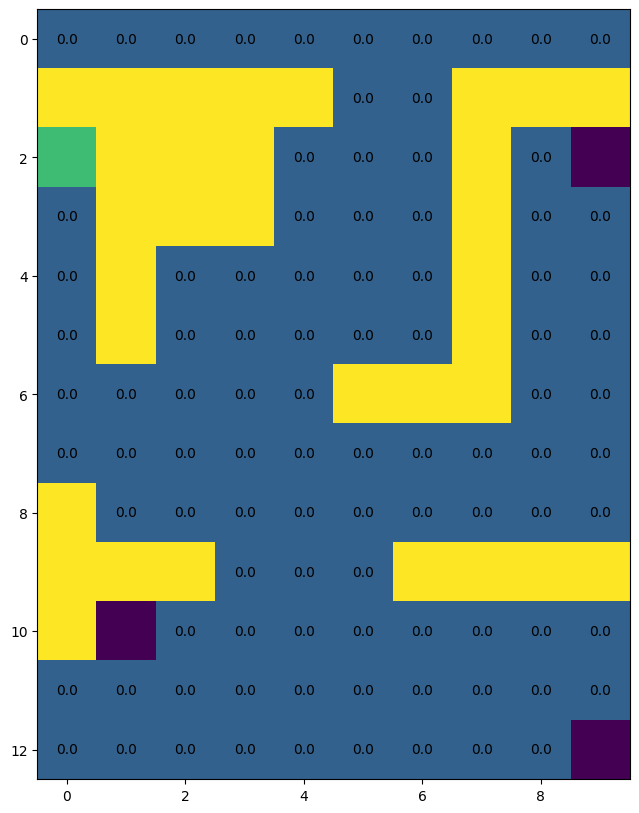

In [ ]:
# Example main (can be edited)

### Question 0: Defining the environment

print("Creating the Maze:\n")
maze = Maze()

### Question 1: Dynamic programming

dp_agent = DP_agent()
dp_policy, dp_value = dp_agent.solve(maze)

print("Results of the DP agent:\n")
maze.get_graphics().draw_policy(dp_policy)
maze.get_graphics().draw_value(dp_value)


### Question 2: Monte-Carlo learning

mc_agent = MC_agent()
mc_policy, mc_values, total_rewards = mc_agent.solve(maze)

print("Results of the MC agent:\n")
maze.get_graphics().draw_policy(mc_policy)
maze.get_graphics().draw_value(mc_values[-1])


### Question 3: Temporal-Difference learning

td_agent = TD_agent()
td_policy, td_values, total_rewards = td_agent.solve(maze)

print("Results of the TD agent:\n")
maze.get_graphics().draw_policy(td_policy)
maze.get_graphics().draw_value(td_values[-1])